# Semi-supervised GMM

## Setup

In [1]:
from pathlib import Path
from pprint import pprint
import datetime as dt

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

# from scipy.stats import norm
from scipy.stats import multivariate_normal
from scipy.fftpack import fft
from scipy.interpolate import make_splrep
from scipy.special import logsumexp

# from sklearn.mixture import GaussianMixture
from sklearn import metrics
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# from tslearn.preprocessing import TimeSeriesScalerMeanVariance
# from tslearn.utils import to_time_series_dataset
from tsfresh.feature_extraction import feature_calculators as feat_calc

import pyLasaDataset as lasa
# from hmmlearn import hmm
# from tqdm.auto import tqdm

Using LASA DataSet from /home/kir0ul/Projects/BayesDistanceClustering/.direnv/python-3.13/lib64/python3.13/site-packages/pyLasaDataset/resources/LASAHandwritingDataset/DataSet


In [2]:
from segmentation_utils import (
    get_ground_truth_segmentation,
    read_h5_data,
    get_gtdict_filenames,
    ts2df,
)

In [3]:
# %matplotlib ipympl
%load_ext autoreload
%autoreload 2

### Hyperparameters

In [4]:
# seed = 0
seed = 42
seq_length = 2**10
print(f"Sequence_length: {seq_length}")
rng = np.random.default_rng(seed)
window_size = 20
window_step = 5

Sequence_length: 1024


In [5]:
# max_iter = 300
tol = 1e-3
beta = 0.5

In [6]:
# Make transparent background plot
TRANSP_BACK_PLOT = True
# TRANSP_BACK_PLOT = False

## Data

In [7]:
# series1 = rng.normal(loc=0, scale=1, size=(seq_length, 2))
# series2 = rng.normal(loc=5, scale=1, size=(seq_length, 2))
# series3 = rng.normal(loc=-3, scale=1, size=(seq_length, 2))
# data = np.stack([series1, series2, series3])
# data.shape

In [8]:
means = np.array(
    [
        [1, 3],
        [3, 1],
        [2.0, 2.0],
    ]
)
covs = np.eye(2) * 0.5
data = np.ones((means.shape[0], seq_length, 2)) * np.nan
for idx in range(means.shape[0]):
    data[idx, :, :] = rng.multivariate_normal(
        mean=means[idx, :], cov=covs, size=(seq_length)
    )
data.shape

(3, 1024, 2)

In [9]:
K_components = data.shape[0]

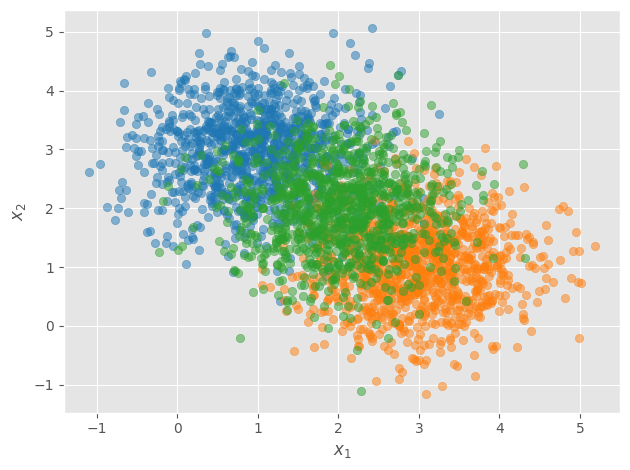

In [10]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots()
    for idx in range(data.shape[0]):
        ax.scatter(data[idx, :, 0], data[idx, :, 1], color=cmap[idx], alpha=0.5)
    ax.set_xlabel(f"$x_1$")
    ax.set_ylabel(f"$x_2$")
    fig.tight_layout()
    plt.show()

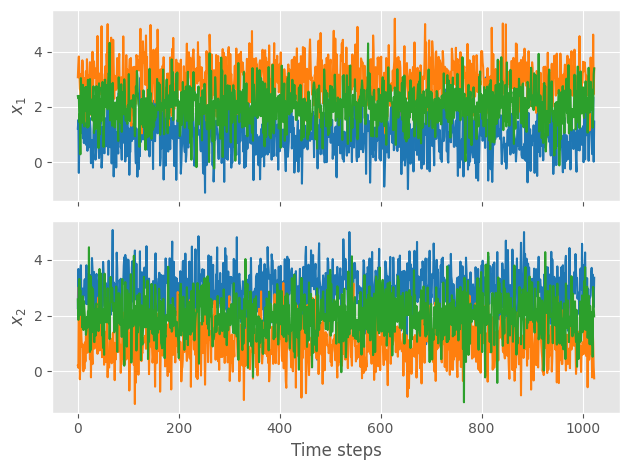

In [11]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots(data.shape[-1], 1, sharex=True)
    for idx in range(data.shape[-1]):
        for jdx in range(data.shape[0]):
            ax[idx].plot(data[jdx, :, idx], c=cmap[jdx])
        ax[idx].set_ylabel(f"$x_{idx + 1}$")
    ax[idx].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

## Preprocessing & feature engineering

In [12]:
# dataset = to_time_series_dataset(data)
# dataset.shape

In [13]:
# scaler = TimeSeriesScalerMeanVariance()
# data_scaled = np.squeeze(scaler.fit_transform(data))
# data_scaled.shape

In [14]:
def sliding_window(series, window_size, step=1):
    windows = []
    for idx in range(0, len(series) - window_size + 1, step):
        windows.append(series[idx : idx + window_size])
    return np.array(windows)

In [15]:
windows = []
for idx in range(data.shape[0]):
    data_sc_i = data[idx, :, :]
    windows.append(
        sliding_window(series=data_sc_i, window_size=window_size, step=window_step)
    )
windows = np.array(windows)
windows.shape

(3, 201, 20, 2)

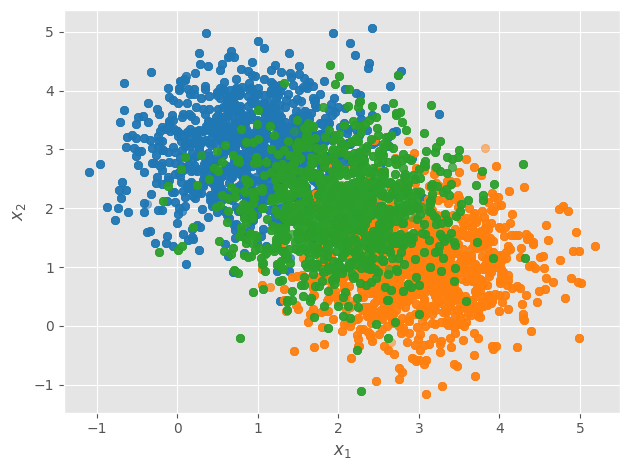

In [16]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots()
    for idx in range(windows.shape[0]):
        for jdx in range(windows.shape[1]):
            ax.scatter(
                windows[idx, jdx, :, 0],
                windows[idx, jdx, :, 1],
                color=cmap[idx],
                alpha=0.5,
            )
    ax.set_xlabel(f"$x_1$")
    ax.set_ylabel(f"$x_2$")
    fig.tight_layout()
    plt.show()

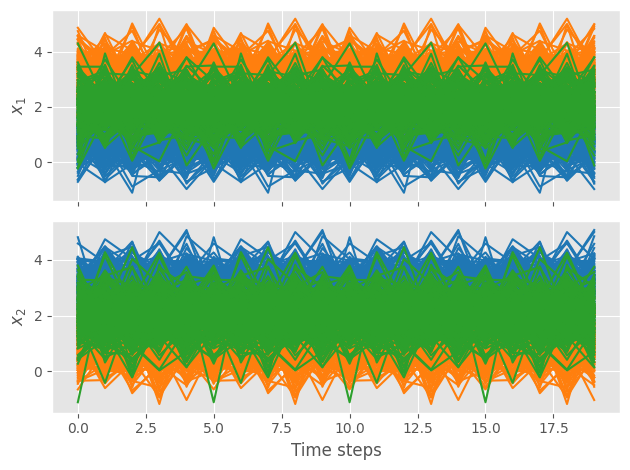

In [17]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots(windows.shape[-1], 1, sharex=True)
    for idx in range(windows.shape[-1]):
        for jdx in range(windows.shape[0]):
            for kdx in range(windows.shape[1]):
                ax[idx].plot(windows[jdx, kdx, :, idx], c=cmap[jdx])
        ax[idx].set_ylabel(f"$x_{idx + 1}$")
    ax[idx].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

In [18]:
def loop_on_col(arr, funct, *args, **kwargs):
    res = []
    for col in range(arr.shape[1]):
        res.append(funct(arr[:, col], *args, **kwargs))
    return res

In [19]:
def extract_features(windows, lag=5, bins=10):
    features = []
    for win in windows:
        feats = [
            # np.mean(win),
            # np.std(win),
            # np.min(win),
            # np.max(win),
            # np.median(win),
            # np.percentile(win, 25),
            # np.percentile(win, 75),
            # *np.abs(fft(win)).flatten()[:5]
            *loop_on_col(arr=win, funct=feat_calc.abs_energy),
            feat_calc.absolute_sum_of_changes(win),
            feat_calc.autocorrelation(x=win, lag=lag),
            *loop_on_col(arr=win, funct=feat_calc.benford_correlation),
            # feat_calc.binned_entropy(x=win, max_bins=bins),
            feat_calc.c3(x=win, lag=lag),
            *loop_on_col(arr=win, funct=feat_calc.cid_ce, normalize=True),
            # *loop_on_col(arr=win, funct=feat_calc.fourier_entropy, bins=bins),
            *loop_on_col(arr=win, funct=feat_calc.kurtosis),
            *loop_on_col(arr=win, funct=feat_calc.lempel_ziv_complexity, bins=bins),
            *loop_on_col(arr=win, funct=feat_calc.longest_strike_above_mean),
            *loop_on_col(arr=win, funct=feat_calc.longest_strike_below_mean),
            feat_calc.mean_abs_change(win),
            *feat_calc.mean_change(win),
            *feat_calc.mean_second_derivative_central(win),
            *loop_on_col(
                arr=win,
                funct=feat_calc.percentage_of_reoccurring_datapoints_to_all_datapoints,
            ),
            *loop_on_col(
                arr=win, funct=feat_calc.percentage_of_reoccurring_values_to_all_values
            ),
            feat_calc.ratio_value_number_to_time_series_length(win),
            feat_calc.root_mean_square(win),
            feat_calc.sample_entropy(win),
            *loop_on_col(arr=win, funct=feat_calc.skewness),
            feat_calc.time_reversal_asymmetry_statistic(x=win, lag=lag),
            feat_calc.variation_coefficient(win),
            # ToDo: add curvature feature
        ]
        features.append(feats)
    return np.array(features)

In [20]:
features = []
for idx in range(windows.shape[0]):
    window_i = windows[idx, :, :]
    features.append(extract_features(window_i))
features = np.array(features)
features.shape

(3, 201, 33)

In [21]:
labels_gt = (
    np.array([np.ones(features.shape[1]) * idx for idx in range(features.shape[0])])
    .flatten()
    .astype(int)
)
labels_gt

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [22]:
labels_gt = (
    np.array([np.ones(data.shape[1]) * idx for idx in range(data.shape[0])])
    .flatten()
    .astype(int)
)
labels_gt

array([0, 0, 0, ..., 2, 2, 2], shape=(3072,))

In [23]:
feat_mat = features.reshape(features.shape[0] * features.shape[1], features.shape[2])
feat_mat = pd.DataFrame(feat_mat)
feat_mat

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,33.933794,172.491524,34.383649,1.302444,0.838551,0.306583,12.582626,7.015794,7.139521,2.211940,...,0.0,0.0,0.0,1.0,2.271703,1.001449,-0.386215,0.389880,0.658751,0.505911
1,36.386221,186.832273,35.321601,1.453545,0.844151,0.251848,14.567852,7.348869,6.469934,0.732647,...,0.0,0.0,0.0,1.0,2.362300,0.854415,0.412449,0.014447,0.965148,0.467563
2,29.368372,196.010353,40.652159,1.481560,0.813111,0.237151,15.358542,6.487957,6.554335,0.533683,...,0.0,0.0,0.0,1.0,2.373703,0.675129,0.482092,0.242589,2.418350,0.548847
3,27.774458,199.532044,42.516367,1.617246,0.863572,0.237151,15.411656,5.827306,6.966480,0.410811,...,0.0,0.0,0.0,1.0,2.383834,0.749237,0.224241,0.171653,0.210300,0.580163
4,21.876526,199.763094,44.882107,1.751985,0.812453,0.212778,15.484381,5.984406,6.321674,-0.969778,...,0.0,0.0,0.0,1.0,2.353931,0.713766,-0.372318,-0.066416,-1.906609,0.610270
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
598,105.788495,61.231631,15.510909,0.628022,0.900491,0.936042,6.973985,5.867597,6.032309,-0.780458,...,0.0,0.0,0.0,1.0,2.043405,0.476924,0.417217,0.062333,1.716698,0.413652
599,107.927534,62.466529,16.828112,0.860887,0.813453,0.964067,7.763762,5.988691,6.056667,-0.676358,...,0.0,0.0,0.0,1.0,2.063941,0.476924,0.223615,0.300656,2.368390,0.410440
600,113.038695,79.395529,18.923411,0.414130,0.813453,0.955663,9.655573,5.960147,5.794001,-0.573397,...,0.0,0.0,0.0,1.0,2.193366,0.371564,0.397541,0.802024,0.551755,0.373770
601,106.436201,89.702187,14.679734,-0.409498,0.847797,0.962863,8.950298,6.122521,6.795532,-0.260859,...,0.0,0.0,0.0,1.0,2.214376,0.342945,0.279104,0.846640,-0.895873,0.321887


In [24]:
feat_mat = data.reshape(data.shape[0] * data.shape[1], data.shape[2])
feat_mat = pd.DataFrame(feat_mat)
feat_mat

,0,1
0,1.215468,2.264620
1,1.530649,3.665080
2,-0.379590,2.079220
3,1.090397,2.776383
4,0.988120,2.396807
...,...,...
3067,2.520470,1.985507
3068,1.251430,0.525961
3069,1.903499,3.023688
3070,3.184181,2.251289


In [25]:
# scaler = StandardScaler()
# feat_mat = scaler.fit_transform(feat_mat)
# feat_mat = pd.DataFrame(feat_mat)
# feat_mat

### Supervised data

In [26]:
# supervised_sample_size = 10
# idx_superv = np.random.choice(
#     np.arange(labels_gt.shape[0]), size=supervised_sample_size, replace=False
# )
# Y = np.zeros((len(idx_superv), K_components))
# for idxi, idx_val in enumerate(idx_superv):
#     Y[idxi, int(labels_gt[int(idx_val)])] = 1
# # Y = labels_gt[idx_superv]
# X = feat_mat.iloc[idx_superv, :]
# X.shape, Y

In [27]:
def select_supervised_data(total_sample_size, labels_gt, K_components, U):
    unique_labels = np.unique(labels_gt)
    label_sample_size = int(np.round(total_sample_size / len(unique_labels)))

    # Select balanced data for each label
    all_idx = np.arange(labels_gt.shape[0])
    idx_superv = []
    for label in unique_labels:
        current_label_mask = labels_gt == label
        current_label_idx = np.array(
            [idx for idx in all_idx if current_label_mask[idx] == True]
        )
        assert len(current_label_idx) >= label_sample_size, (
            f"Not enough data points to select {label_sample_size} samples for class {label}, only {len(current_label_idx)} found"
        )
        idx_superv.extend(
            np.random.choice(current_label_idx, size=label_sample_size, replace=False)
        )
    idx_superv = np.array(idx_superv)

    # Build the Y matrix
    Y = np.zeros((len(idx_superv), K_components))
    for idxi, idx_val in enumerate(idx_superv):
        Y[idxi, int(labels_gt[int(idx_val)])] = 1

    X = U[idx_superv, :]
    return X, Y, idx_superv

In [28]:
supervised_sample_size = 10
X, Y, _ = select_supervised_data(
    total_sample_size=supervised_sample_size,
    labels_gt=labels_gt,
    K_components=K_components,
    U=feat_mat.to_numpy(),
)
X.shape, Y

((9, 2),
 array([[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.]]))

## GMM clustering

In [29]:
def e_step(U, pi_mixing_prior, mu, Sigma, seed=None, allow_singular=False):
    """
    Compute the expectation step (equation 4).

    U: unlabeled training data
    """
    N = U.shape[0]
    K = pi_mixing_prior.shape[0]
    log_probs = np.zeros((N, K))

    for n in range(N):
        for k in range(K):
            log_probs[n, k] = np.log(pi_mixing_prior[k]) + multivariate_normal.logpdf(
                x=U[n, :], mean=mu[k], cov=Sigma[k], allow_singular=allow_singular
            )
    log_norm = logsumexp(log_probs, axis=1, keepdims=True)
    gamma_resp = np.exp(log_probs - log_norm)
    return gamma_resp

In [30]:
def m_step(gamma_resp, U, X=None, Y=None, beta=0.5, reg_coef=1e-3):
    """
    Compute the maximization step.
    """
    if X is None or Y is None:
        # Fall back to unsupervised
        beta = 0
        M = 0
    else:
        assert X.shape[0] == Y.shape[0], "X and Y must have the same number of rows"
        assert U.shape[1] == X.shape[1], "U and X must have the same number of columns"
        M, _ = X.shape
    N, D = U.shape
    K = gamma_resp.shape[1]

    pi_mixing_prior_new = np.zeros(K) * np.nan
    mu_new = np.zeros((K, D)) * np.nan
    Sigma_new = np.zeros((K, D, D)) * np.nan

    for k in range(K):
        if beta == 0:
            common_term = (1 - beta) * gamma_resp.sum(axis=0)[k]
        else:
            common_term = (1 - beta) * gamma_resp.sum(axis=0)[k] + beta * Y.sum(axis=0)[
                k
            ]

        # Update mixing coefficients (equation 5)
        pi_mixing_prior_new[k] = common_term / ((1 - beta) * N + beta * M)

        # Update means (equation 6)
        gamma_resp_u = 0
        gamma_resp_x = 0
        for n in range(N):
            gamma_resp_u += gamma_resp[n, k] * U[n, :]
        if beta == 0:
            gamma_resp_x = 0
        else:
            for m in range(M):
                gamma_resp_x += gamma_resp[m, k] * X[m, :]
        mu_new[k, :] = ((1 - beta) * gamma_resp_u + beta * gamma_resp_x) / common_term

        # Update covariances (equation 7)
        gamma_resp_u_mu = 0
        gamma_resp_x_mu = 0
        for n in range(N):
            gamma_resp_u_mu += (
                gamma_resp[n, k] * (U[n, :] - mu_new[k]) * (U[n, :] - mu_new[k]).T
            )
        if beta == 0:
            gamma_resp_x_mu = 0
        else:
            for m in range(M):
                gamma_resp_x_mu += (
                    gamma_resp[n, k] * (X[m, :] - mu_new[k]) * (X[m, :] - mu_new[k]).T
                )
        # Sigma_new[k] = ((1 - beta) * gamma_resp_u_mu) / common_term + (
        #     beta * gamma_resp_x_mu
        # ) / common_term
        var = ((1 - beta) * gamma_resp_u_mu) / common_term + (
            beta * gamma_resp_x_mu
        ) / common_term
        # var = 1/2*(var + var.T)  # Semi Positive Definite issue
        # # regularization for numerical stability (optional, small jitter)
        # Sigma_new[k] += reg_coef*np.eye(D)

        # # Constrain the covariance matrices to be diagonal
        # var = (gamma_resp[:, k][:, None] * diff**2).sum(axis=0) / Nk[k]
        Sigma_new[k] = np.diag(var + reg_coef)
    return pi_mixing_prior_new, mu_new, Sigma_new

In [31]:
def log_likelihood(
    pi_mixing_prior, mu, Sigma, U, X=None, Y=None, beta=0.5, allow_singular=False
):
    """
    Compute the log-likelihood (equation 9).
    """
    if X is None or Y is None:
        # Fall back to unsupervised
        beta = 0
    else:
        assert X.shape[0] == Y.shape[0], "X and Y must have the same number of rows"
        assert U.shape[1] == X.shape[1], "U and X must have the same number of columns"
        M, _ = X.shape
    N, D = U.shape
    K = pi_mixing_prior.shape[0]
    log_probs = np.zeros((N, K))
    log_lik_unsuperv = np.zeros((N, K))
    log_lik_superv = np.zeros((N, K))

    for n in range(N):
        for k in range(K):
            log_probs[n, k] = np.log(pi_mixing_prior[k]) + multivariate_normal.logpdf(
                x=U[n, :], mean=mu[k], cov=Sigma[k], allow_singular=allow_singular
            )
    log_norm = logsumexp(log_probs, axis=1, keepdims=True)
    log_lik_unsuperv = (1 - beta) * log_norm.sum(axis=0)

    if beta == 0:
        log_lik_superv = 0
    else:
        for m in range(M):
            for k in range(K):
                # ToDo: may need to convert the multiplication by `Y[m, k]` to a sum of log
                log_lik_superv[m, k] = Y[m, k] * np.log(
                    pi_mixing_prior[k]
                ) + multivariate_normal.logpdf(
                    x=X[m, :], mean=mu[k], cov=Sigma[k], allow_singular=allow_singular
                )
        log_lik_superv = beta * log_lik_superv.sum()

    return log_lik_unsuperv + log_lik_superv

In [32]:
def run_EM(
    K_components,
    U,
    X=None,
    Y=None,
    beta=0.5,
    reg_coef=1e-3,
    max_iter=300,
    tol=1e-6,
    seed=None,
    allow_singular=False,
):
    """
    Expectation-Maximization algorithm.

    Implemented from [1].

    [1] Yan, H.-C., Zhou, J.-H., & Pang, C. K. (2017).
    Gaussian Mixture Model Using Semisupervised Learning for Probabilistic Fault Diagnosis Under New Data Categories.
    IEEE Transactions on Instrumentation and Measurement, 66(4), 723–733.
    https://doi.org/10.1109/TIM.2017.2654552

    """
    if X is None or Y is None:
        # Fall back to unsupervised
        beta = 0

    # Initialization
    N, D = U.shape
    pi_mixing_prior = np.ones(K_components) / K_components
    # pi_mixing_prior = np.random.uniform(size=K_components)
    # pi_mixing_prior = pi_mixing_prior/pi_mixing_prior.sum()
    # mu = np.random.rand(K_components, D) * 10.0
    kmeans_init = KMeans(n_clusters=K_components, random_state=seed).fit(X=U)
    mu = np.array(kmeans_init.cluster_centers_)
    # Sigma = np.array([np.eye(D) * rng.uniform(low=0, high=0.01, size=D) for _ in range(K_components)])
    Sigma = np.array([np.eye(D) for _ in range(K_components)])

    lls = []
    for it in range(max_iter):
        # E-step
        gamma_resp = e_step(
            U=U, pi_mixing_prior=pi_mixing_prior, mu=mu, Sigma=Sigma, seed=seed
        )

        # M-step
        pi_mixing_prior, mu, Sigma = m_step(
            U=U, X=X, Y=Y, gamma_resp=gamma_resp, reg_coef=reg_coef
        )

        # Log-likelihood
        ll = log_likelihood(
            U=U,
            X=X,
            Y=Y,
            pi_mixing_prior=pi_mixing_prior,
            mu=mu,
            Sigma=Sigma,
            allow_singular=allow_singular,
        )
        lls.append(ll)

        # Logging during training
        if it % 10 == 0:
            # plot_gmm(X, mu, Sigma, title=f'GMM Contours — Iteration {it+1}')
            print(f"Iteration {it:>3}/{max_iter} -- Log-likelihood: {ll[0]}")

        # Convergence check
        if it > 0 and abs(lls[-1] - lls[-2]) < tol:
            print(f"\n--- Converged at iteration {it + 1} ---\n")
            break

    with plt.style.context("ggplot"):
        fig, ax = plt.subplots()
        ax.plot(lls, marker=".", c="k")
        ax.set_title("EM training")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Log-likelihood")
        # ax.set_grid(True, alpha=0.3)
        plt.show()

    labels_pred = np.argmax(gamma_resp, axis=1)
    return mu, Sigma, gamma_resp, labels_pred, pi_mixing_prior

In [33]:
def predict(U, pi_mixing_prior, mu, Sigma, allow_singular=False, seed=None):
    gamma_resp = e_step(
        U=U, pi_mixing_prior=pi_mixing_prior, mu=mu, Sigma=Sigma, seed=seed
    )
    uncertainty = 1 - gamma_resp.max(axis=1)
    labels_pred = np.argmax(gamma_resp, axis=1)

    N = U.shape[0]
    K = pi_mixing_prior.shape[0]
    log_probs = np.zeros((N, K))

    for n in range(N):
        for k in range(K):
            log_probs[n, k] = np.log(pi_mixing_prior[k]) + multivariate_normal.logpdf(
                x=U[n, :], mean=mu[k], cov=Sigma[k], allow_singular=allow_singular
            )
    # proba = np.exp(log_probs.sum(axis=1))
    proba = np.exp(log_probs).sum(axis=1)
    # proba = logsumexp(log_probs, axis=1)

    return gamma_resp, labels_pred, uncertainty, proba

Iteration   0/300 -- Log-likelihood: -4344.874684979463
Iteration  10/300 -- Log-likelihood: -4324.708744270333
Iteration  20/300 -- Log-likelihood: -4323.61410112874
Iteration  30/300 -- Log-likelihood: -4323.129583619096
Iteration  40/300 -- Log-likelihood: -4322.958067823786
Iteration  50/300 -- Log-likelihood: -4322.919727961425

--- Converged at iteration 51 ---



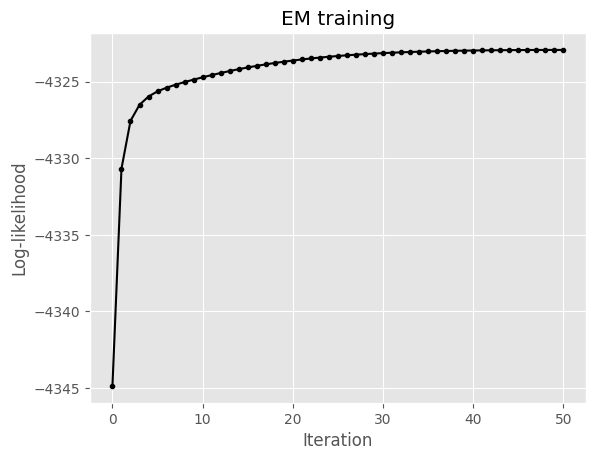

In [34]:
reg_coef = 1e-5
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    K_components=K_components,
    U=feat_mat.to_numpy(),
    X=X,
    Y=Y,
    beta=beta,
    reg_coef=reg_coef,
    tol=tol,
    seed=seed,
    allow_singular=False,
)

In [35]:
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

(array([[2.90780077, 1.00470339],
        [1.10175221, 2.96678422],
        [2.08421908, 1.89268232]]),
 array([[[0.56124697, 0.        ],
         [0.        , 0.49174958]],
 
        [[0.57831148, 0.        ],
         [0.        , 0.46684386]],
 
        [[0.59840383, 0.        ],
         [0.        , 0.399723  ]]]),
 array([[1.51939477e-02, 6.28703145e-01, 3.56102908e-01],
        [2.43569837e-04, 9.77806315e-01, 2.19501155e-02],
        [2.67166406e-04, 9.35910793e-01, 6.38220406e-02],
        ...,
        [8.12797501e-03, 7.90265747e-01, 2.01606278e-01],
        [4.20094040e-01, 3.24922963e-02, 5.47413664e-01],
        [6.14548048e-01, 8.01052481e-03, 3.77441427e-01]], shape=(3072, 3)),
 array([1, 1, 1, ..., 1, 2, 0], shape=(3072,)),
 array([0.35159238, 0.38286374, 0.26554388]))

In [36]:
# with plt.style.context("ggplot"):
#     cmap = plt.colormaps["tab10"].colors
#     fig, ax = plt.subplots()
#     for idx in range(data.shape[0]):
#         ax.scatter(data[idx, :, 0], data[idx, :, 1], color="k", alpha=0.4)
#     ax.set_xlabel(f"$x_1$")
#     ax.set_ylabel(f"$x_2$")

#     # xg, yg = np.meshgrid(np.linspace(-5, 15, 100), np.linspace(-5, 15, 100))
#     # pos = np.dstack((xg, yg))
#     # for jdx in range(K_components):
#     #     rv = rng.multivariate_normal(
#     #         mean=gmm.means_[jdx], cov=gmm.covariances_[jdx]
#     #     )
#     #     # ax.contour(xg, yg, rv.pdf(pos), levels=5, colors=cmap[jdx], alpha=0.8)
#     #     ax.scatter(gmm.means_[jdx, 0], gmm.means_[jdx, 1], c="k")#, color=cmap[jdx], marker="x", s=100)

#     fig.tight_layout()
#     plt.show()

### Metrics

In [37]:
# accu = accuracy_score(y_true=labels_gt, y_pred=clust_labels_pred)
# print(f"Accuracy: {accu}")

In [38]:
def print_metrics(X, labels_true, labels_pred):
    print(f"Silhouette: {metrics.silhouette_score(X=X, labels=labels_pred)}")
    print(
        f"Completeness: {metrics.completeness_score(labels_true=labels_true, labels_pred=labels_pred)}"
    )
    print(
        f"Fowlkes-Mallows index: {metrics.fowlkes_mallows_score(labels_true=labels_true, labels_pred=labels_pred)}"
    )
    print(
        f"Homogeneity: {metrics.homogeneity_score(labels_true=labels_true, labels_pred=labels_pred)}"
    )
    print(
        f"Mutual Information: {metrics.mutual_info_score(labels_true=labels_true, labels_pred=labels_pred)}"
    )
    print(
        f"Adjusted mutual information: {metrics.adjusted_mutual_info_score(labels_true=labels_true, labels_pred=labels_pred)}"
    )
    print(
        f"Normalized Mutual Information: {metrics.normalized_mutual_info_score(labels_true=labels_true, labels_pred=labels_pred)}"
    )
    print(
        f"Rand index: {metrics.rand_score(labels_true=labels_true, labels_pred=labels_pred)}"
    )
    print(
        f"Adjusted rand index: {metrics.adjusted_rand_score(labels_true=labels_true, labels_pred=labels_pred)}"
    )
    print(
        f"V-measure: {metrics.v_measure_score(labels_true=labels_true, labels_pred=labels_pred)}"
    )

In [39]:
print_metrics(X=feat_mat, labels_true=labels_gt, labels_pred=clust_labels_pred)

Silhouette: 0.31621478116819407
Completeness: 0.46196664838328544
Fowlkes-Mallows index: 0.6550948566956394
Homogeneity: 0.45466351645681247
Mutual Information: 0.4994989263885096
Adjusted mutual information: 0.45796192228092425
Normalized Mutual Information: 0.45828598904194434
Rand index: 0.7663131410778248
Adjusted rand index: 0.47839563160709925
V-measure: 0.45828598904194445


In [40]:
def plot_cluster_res3(U, X, Y, labels_gt, labels_pred, gamma_resp, mu):

    # Transform data to first two principal components for plotting
    pca = PCA(n_components=2)
    U_pca = pca.fit_transform(U)
    X_pca = pca.transform(X)
    mu_pca = pca.transform(mu)

    uncertainty = 1 - gamma_resp.max(axis=1)

    with plt.style.context("ggplot"):
        fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(13, 4))
        ax[0].scatter(U_pca[:, 0], U_pca[:, 1], c=labels_gt, alpha=0.5, s=20)
        ax[0].scatter(
            X_pca[:, 0],
            X_pca[:, 1],
            marker="+",
            c="k",
            alpha=0.5,
            s=20,
            label="Supervised data",
        )
        ax[0].set_title("True clusters")
        ax[1].scatter(U_pca[:, 0], U_pca[:, 1], c=labels_pred, alpha=0.5, s=20)
        ax[1].scatter(
            X_pca[:, 0],
            X_pca[:, 1],
            marker="+",
            c="k",
            alpha=0.5,
            s=20,
            label="Supervised data",
        )
        ax[1].scatter(
            mu_pca[:, 0],
            mu_pca[:, 1],
            marker="x",
            c="r",
            alpha=1,
            s=50,
            label=r"$\mu$",
        )
        ax[1].set_title("Predicted clusters")
        ax[2].scatter(U_pca[:, 0], U_pca[:, 1], c=uncertainty, alpha=0.5, s=20)
        ax[2].set_title("Uncertainty")
        for axi in ax:
            axi.set_xlabel("PC 1")
            axi.set_ylabel("PC 2")
        for axi in ax[:2]:
            axi.legend(
                loc="best", facecolor="white"
            )  # , edgecolor='black', fancybox=True)
        fig.tight_layout()
        plt.show()

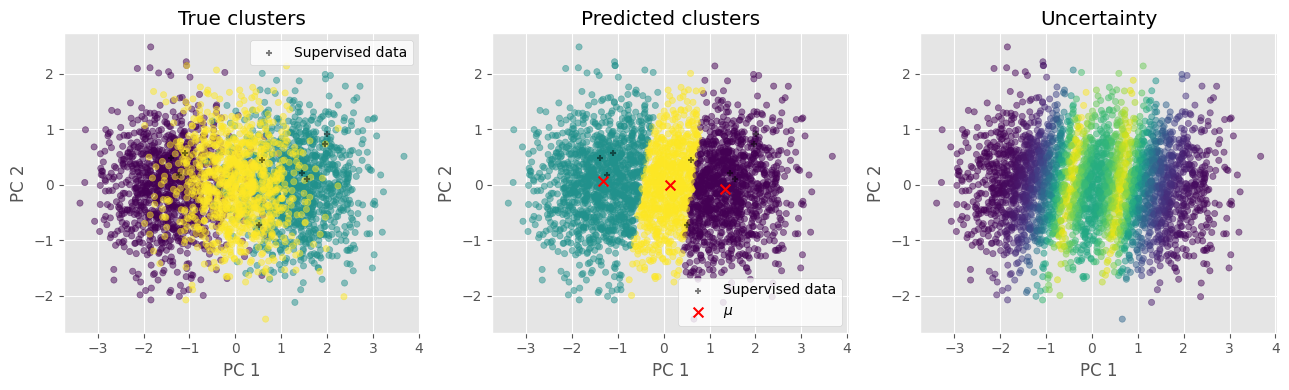

In [41]:
plot_cluster_res3(
    U=feat_mat,
    X=X,
    Y=Y,
    labels_gt=labels_gt,
    labels_pred=clust_labels_pred,
    gamma_resp=gamma_resp,
    mu=mu,
)

### New data

In [42]:
# new_data = np.random.normal(6, 1, 70)
# new_feat = np.array([np.mean(new_data), np.std(new_data)])[np.newaxis, :]
# new_feat

In [43]:
new_data = rng.multivariate_normal(
    mean=np.array([6, 1]), cov=covs, size=(seq_length * 2)
)
new_data.shape

(2048, 2)

In [44]:
# new_data_scaled = np.squeeze(scaler.transform(new_data))
# new_data_scaled.shape

In [45]:
new_windows = sliding_window(series=new_data, window_size=window_size, step=window_step)
new_windows.shape

(406, 20, 2)

In [46]:
new_feat_mat = pd.DataFrame(extract_features(new_windows))
new_feat_mat

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,699.672418,30.150600,98.802293,1.931840,-0.373340,0.874877,104.293648,6.215191,7.763663,-0.852305,...,0.0,0.0,0.0,1.0,4.271484,0.681718,-0.065278,0.115676,9.394265,0.775167
1,740.527670,29.931202,102.361034,1.855218,-0.400441,0.854870,111.374646,6.308006,7.390035,-0.656096,...,0.0,0.0,0.0,1.0,4.388789,0.581356,-0.343080,0.010064,-12.676184,0.780221
2,754.596287,24.457815,105.145926,1.749591,-0.386906,0.818849,113.391603,6.454712,7.785400,-0.152852,...,0.0,0.0,0.0,1.0,4.413202,0.651989,-0.539145,-0.258115,4.465815,0.794097
3,750.212554,20.828531,103.753963,1.871668,-0.363186,0.824397,110.914114,6.362477,6.355211,-0.213802,...,0.0,0.0,0.0,1.0,4.390447,0.883768,-0.550004,-0.175943,13.653546,0.773013
4,802.089290,19.403570,109.120998,1.890169,-0.331912,0.689658,125.040410,6.719251,5.602764,-0.787185,...,0.0,0.0,0.0,1.0,4.531812,0.741937,-0.310731,0.029918,8.519230,0.777642
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401,732.816111,24.611512,104.197050,1.978828,-0.247033,0.770682,109.879272,7.566131,5.113173,-0.619430,...,0.0,0.0,0.0,1.0,4.351516,0.649527,0.317332,0.788428,1.155425,0.780754
402,715.543769,23.077317,104.212392,1.913529,-0.235827,0.752479,105.991580,7.382610,5.864830,-0.860866,...,0.0,0.0,0.0,1.0,4.297153,0.675551,0.300224,0.676658,-10.109137,0.799337
403,718.216774,27.798219,103.042535,1.782118,-0.232100,0.904072,106.198735,7.106485,6.177259,-0.271414,...,0.0,0.0,0.0,1.0,4.318608,0.758286,0.562076,0.451598,-5.475665,0.789571
404,718.964026,28.433100,101.879089,1.827547,-0.256915,0.898276,105.623560,6.633465,6.478522,0.416088,...,0.0,0.0,0.0,1.0,4.322607,0.880889,0.845894,0.430475,10.467570,0.774891


In [47]:
new_feat_mat = pd.DataFrame(new_data)
new_feat_mat

,0,1
0,6.674087,0.680932
1,5.636124,0.520929
2,4.542986,1.910112
3,5.546297,0.433297
4,5.165634,0.855496
...,...,...
2043,6.978010,1.056107
2044,6.575088,1.716164
2045,6.188650,0.424068
2046,6.138104,1.853529


In [48]:
# new_feat_scaled = scaler.fit_transform(new_feat)
# new_feat_scaled = pd.DataFrame(new_feat_scaled)
# new_feat_scaled

In [49]:
feat_mat_concat = pd.concat((feat_mat, new_feat_mat))
feat_mat_concat

,0,1
0,1.215468,2.264620
1,1.530649,3.665080
2,-0.379590,2.079220
3,1.090397,2.776383
4,0.988120,2.396807
...,...,...
2043,6.978010,1.056107
2044,6.575088,1.716164
2045,6.188650,0.424068
2046,6.138104,1.853529


In [50]:
labels_gt_new = np.ones(new_data.shape[0]).astype(int) * 3
labels_gt_new

array([3, 3, 3, ..., 3, 3, 3], shape=(2048,))

In [51]:
labels_gt_concat = np.concat((labels_gt, labels_gt_new), axis=0)
labels_gt_concat

array([0, 0, 0, ..., 3, 3, 3], shape=(5120,))

In [52]:
gamma_resp, labels_pred, uncertainty, proba = predict(
    U=feat_mat_concat.to_numpy(),
    pi_mixing_prior=pi_mixing_prior,
    mu=mu,
    Sigma=Sigma,
    allow_singular=False,
    seed=seed,
)
gamma_resp, labels_pred, uncertainty, proba

(array([[1.52057262e-02, 6.29003554e-01, 3.55790720e-01],
        [2.42862140e-04, 9.78085286e-01, 2.16718516e-02],
        [2.68294807e-04, 9.35589117e-01, 6.41425885e-02],
        ...,
        [9.99134199e-01, 4.27878635e-09, 8.65796407e-04],
        [9.80425268e-01, 1.94109562e-06, 1.95727904e-02],
        [9.91576131e-01, 2.56136187e-07, 8.42361298e-03]], shape=(5120, 3)),
 array([1, 1, 1, ..., 0, 0, 0], shape=(5120,)),
 array([0.37099645, 0.02191471, 0.06441088, ..., 0.0008658 , 0.01957473,
        0.00842387], shape=(5120,)),
 array([1.08732564e-01, 6.06652607e-02, 8.08602461e-03, ...,
        5.17984154e-06, 4.79262858e-06, 1.81705598e-06], shape=(5120,)))

In [53]:
proba.min(), proba.max(), proba.sum(), proba

(np.float64(4.1558831419734476e-13),
 np.float64(0.13573349366802956),
 np.float64(243.09027345107475),
 array([1.08732564e-01, 6.06652607e-02, 8.08602461e-03, ...,
        5.17984154e-06, 4.79262858e-06, 1.81705598e-06], shape=(5120,)))

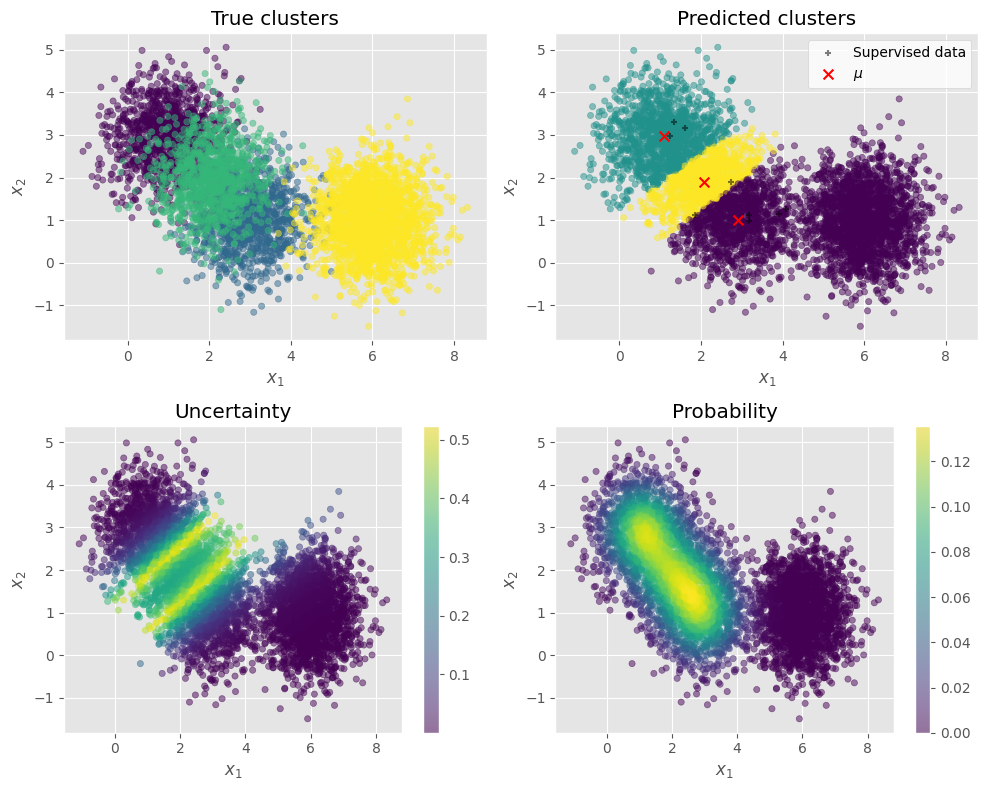

In [54]:
# # Transform data to first two principal components for plotting
# pca = PCA(n_components=2)
# U_pca = pca.fit_transform(new_feat_mat.to_numpy())
# X_pca = pca.transform(feat_mat.to_numpy())
# mu_pca = pca.transform(mu)

U = feat_mat_concat.to_numpy()


with plt.style.context("ggplot"):
    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
    ax[0, 0].scatter(U[:, 0], U[:, 1], alpha=0.5, s=20, c=labels_gt_concat)
    ax[0, 0].set_title("True clusters")
    ax[0, 1].scatter(U[:, 0], U[:, 1], alpha=0.5, s=20, c=labels_pred)
    ax[0, 1].scatter(
        X[:, 0],
        X[:, 1],
        marker="+",
        c="k",
        alpha=0.5,
        s=20,
        label="Supervised data",
    )
    ax[0, 1].scatter(
        mu[:, 0],
        mu[:, 1],
        marker="x",
        c="r",
        alpha=1,
        s=50,
        label=r"$\mu$",
    )
    ax[0, 1].set_title("Predicted clusters")
    scat_u = ax[1, 0].scatter(U[:, 0], U[:, 1], alpha=0.5, s=20, c=uncertainty)
    ax[1, 0].set_title("Uncertainty")
    fig.colorbar(scat_u, ax=ax[1, 0])
    scat_p = ax[1, 1].scatter(U[:, 0], U[:, 1], alpha=0.5, s=20, c=proba)
    ax[1, 1].set_title("Probability")
    fig.colorbar(scat_p, ax=ax[1, 1])
    for axi in ax.flatten():
        # axi.set_xlabel("PC 1")
        # axi.set_ylabel("PC 2")
        axi.set_xlabel(f"$x_1$")
        axi.set_ylabel(f"$x_2$")
    # for axi in ax[:2]:
    ax[0, 1].legend(loc="best", facecolor="white")
    fig.tight_layout()
    plt.show()

In [55]:
# from tslearn.preprocessing import TimeSeriesScalerMeanVariance
# from tslearn.clustering import TimeSeriesKMeans
# from tslearn.utils import to_time_series_dataset

# np.random.seed(0)
# time = np.linspace(0, 10, 50)
# series = [np.sin(time + shift) for shift in np.linspace(0, 3, 10)]
# dataset = to_time_series_dataset(series)

# scaler = TimeSeriesScalerMeanVariance()
# dataset_scaled = scaler.fit_transform(dataset)

# model = TimeSeriesKMeans(n_clusters=3, metric="dtw", random_state=0)
# labels = model.fit_predict(dataset_scaled)

# print("Cluster Labels (Shape-Based):", labels)

## Lasa

In [56]:
resample_num = 2**10
print(f"Resampling to {resample_num} data points")
smoothing_factor = 0

Resampling to 1024 data points


In [57]:
def smooth_arr(arr, nb_points=256, smoothing_factor=0):
    index_ori = np.arange(start=0, stop=arr.shape[0])
    new_index = np.linspace(start=0, stop=arr.shape[0], num=nb_points)
    arr_smooth = make_splrep(x=index_ori, y=arr, s=smoothing_factor)(new_index)
    return arr_smooth

In [58]:
datasets = [lasa.DataSet.heee, lasa.DataSet.Line, lasa.DataSet.Saeghe]
X = None
labels_gt = None
for idx, data in enumerate(datasets):
    # dt = data.dt
    demos = data.demos
    demo_id = 0
    demo = demos[demo_id]
    pos = demo.pos.T
    pos_resampled = smooth_arr(
        arr=pos, nb_points=resample_num, smoothing_factor=smoothing_factor
    )
    # pos_resampled = pos
    if X is None:
        X = np.hstack((np.arange(pos_resampled.shape[0])[:, np.newaxis], pos_resampled))
        labels_gt = np.ones((pos_resampled.shape[0],), dtype=int) * idx
    else:
        # dist_from_last_point = np.abs(X[-1, :] - pos_resampled[0, :])
        pos_with_time = np.hstack(
            (np.arange(pos_resampled.shape[0])[:, np.newaxis], pos_resampled)
        )
        # X = np.vstack((X, pos_resampled - dist_from_last_point))
        X = np.vstack((X, pos_with_time))
        labels_gt = np.hstack(
            (labels_gt, np.ones(pos_resampled.shape[0], dtype=int) * idx)
        )
# X = np.hstack((np.arange(X.shape[0])[:, np.newaxis], X))
print(X.shape)
print(labels_gt.shape)
dataset = pd.DataFrame(
    {
        "t": X[:, 0],
        "pos_x": X[:, 1],
        "pos_y": X[:, 2],
        "y_cls": labels_gt,
    }
)
dataset

(3072, 3)
(3072,)


,t,pos_x,pos_y,y_cls
0,0.0,-31.414643,18.078238,0
1,1.0,-31.414425,18.078527,0
2,2.0,-31.413891,18.079220,0
3,3.0,-31.413022,18.080319,0
4,4.0,-31.411800,18.081830,0
...,...,...,...,...
3067,1019.0,0.001816,0.001816,2
3068,1020.0,0.000857,0.000857,2
3069,1021.0,0.000250,0.000250,2
3070,1022.0,-0.000002,-0.000002,2


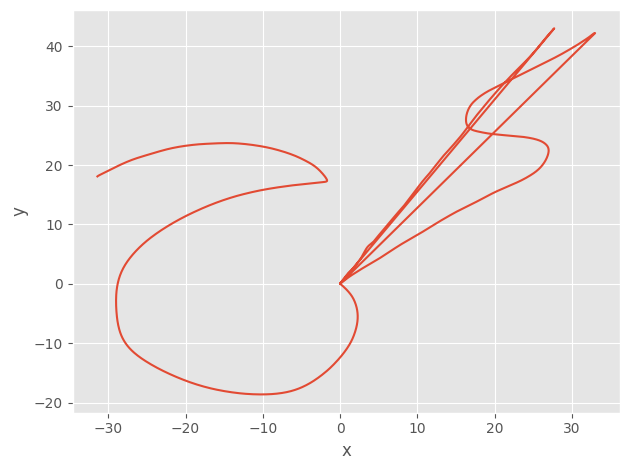

In [59]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots()
    ax.plot(dataset.pos_x, dataset.pos_y)  # , c=blobs[1], alpha=0.5, s=20)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.tight_layout()
    plt.show()

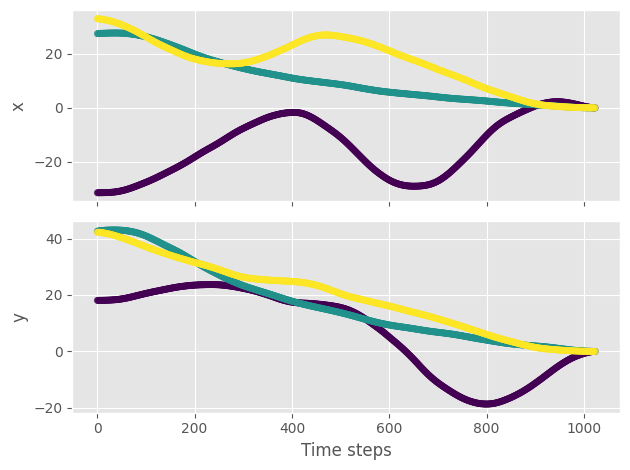

In [60]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots(2, 1, sharex=True)
    ax[0].scatter(dataset.t, dataset.pos_x, c=dataset.y_cls, alpha=0.5, s=20)
    ax[1].scatter(dataset.t, dataset.pos_y, c=dataset.y_cls, alpha=0.5, s=20)
    ax[0].set_ylabel("x")
    ax[1].set_ylabel("y")
    ax[1].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

In [61]:
dataset[["pos_x", "pos_y"]]

,pos_x,pos_y
0,-31.414643,18.078238
1,-31.414425,18.078527
2,-31.413891,18.079220
3,-31.413022,18.080319
4,-31.411800,18.081830
...,...,...
3067,0.001816,0.001816
3068,0.000857,0.000857
3069,0.000250,0.000250
3070,-0.000002,-0.000002


In [62]:
# scaler = TimeSeriesScalerMeanVariance()
# ds_scaled = np.squeeze(scaler.fit_transform(dataset[["pos_x", "pos_y"]]))
# ds_scaled.shape

In [63]:
windows = sliding_window(
    series=dataset[["pos_x", "pos_y"]], window_size=window_size, step=window_step
)
windows.shape

(611, 20, 2)

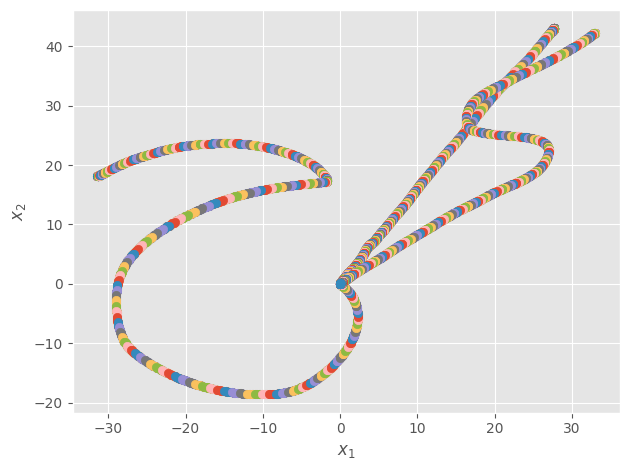

In [64]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots()
    for idx in range(windows.shape[0]):
        ax.scatter(windows[idx, :, 0], windows[idx, :, 1])  # , color=cmap[idx])
    ax.set_xlabel(f"$x_1$")
    ax.set_ylabel(f"$x_2$")
    fig.tight_layout()
    plt.show()

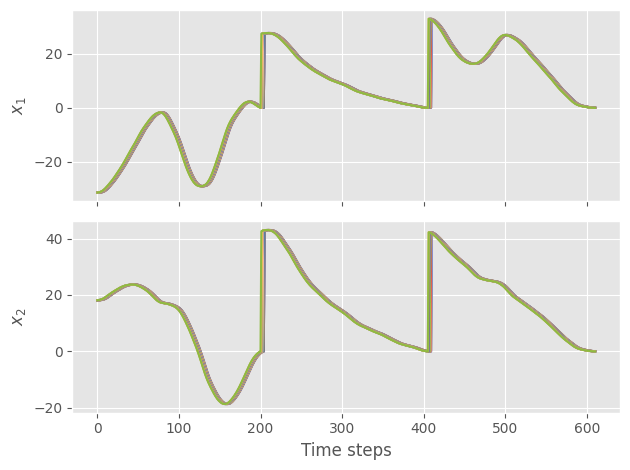

In [65]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots(windows.shape[-1], 1, sharex=True)
    for idx in range(windows.shape[-1]):
        for jdx in range(windows.shape[1]):
            ax[idx].plot(windows[:, jdx, idx])  # , c=cmap[jdx])
        ax[idx].set_ylabel(f"$x_{idx + 1}$")
    ax[idx].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

In [66]:
feat_mat = extract_features(windows)
feat_mat.shape

(611, 33)

In [67]:
for col in range(feat_mat.shape[1]):
    if np.any(np.isnan(feat_mat[:, col])):
        feat_mat = np.delete(arr=feat_mat, obj=col, axis=1)
feat_mat = pd.DataFrame(feat_mat)
feat_mat

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,19710.185086,6553.995510,9.899057e+02,2.000005,0.062915,0.864123,-12502.864336,0.810635,0.787044,-0.983799,...,0.0,0.0,0.0,1.0,25.624295,0.109637,0.579770,0.502830,44.651903,-3.724154
1,19684.603405,6568.927752,9.899100e+02,2.000029,0.062915,0.864123,-12462.608224,0.824128,0.787072,-0.840964,...,0.0,0.0,0.0,1.0,25.619100,0.109637,0.490137,0.339678,62.937180,-3.735692
2,19645.857839,6589.424174,9.898566e+02,2.000069,0.062915,0.864123,-12403.086448,0.837722,0.801492,-0.764577,...,0.0,0.0,0.0,1.0,25.610194,0.109637,0.587807,0.407010,88.333756,-3.752242
3,19590.080828,6616.078284,9.896985e+02,2.000105,0.062915,0.864123,-12319.365978,0.818766,0.793377,-0.856221,...,0.0,0.0,0.0,1.0,25.595976,0.109637,0.560341,0.419324,127.921645,-3.774886
4,19510.215652,6651.133298,9.893815e+02,2.000130,0.062915,0.864123,-12201.687448,0.804125,0.787087,-0.938412,...,0.0,0.0,0.0,1.0,25.574083,0.109637,0.491801,0.390800,179.918478,-3.806204
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,0.285852,0.285852,1.738956e-13,0.744907,0.731806,0.731806,0.001393,0.759377,0.759377,-1.181497,...,0.0,0.0,0.0,1.0,0.119552,0.062132,0.163227,0.163227,-0.001618,0.303686
607,0.167250,0.167250,1.375358e-13,0.743562,0.635832,0.635832,0.000578,0.760394,0.760394,-1.173268,...,0.0,0.0,0.0,1.0,0.091447,0.068993,0.202042,0.202042,-0.000820,0.356909
608,0.089529,0.089529,1.476874e-13,0.740192,0.271055,0.271055,0.000200,0.769863,0.769863,-1.140704,...,0.0,0.0,0.0,1.0,0.066906,0.073025,0.246157,0.246157,-0.000364,0.430301
609,0.042337,0.042337,1.378507e-13,0.725856,0.636766,0.636766,0.000049,0.768502,0.768502,-1.120405,...,0.0,0.0,0.0,1.0,0.046009,0.073025,0.235334,0.235334,-0.000136,0.564052


In [68]:
y_cls_win = np.round(
    np.mean(
        sliding_window(series=dataset.y_cls, window_size=window_size, step=window_step),
        axis=1,
        dtype=int,
    )
)

In [69]:
K_components = len(datasets)
K_components

3

In [70]:
supervised_sample_size = 50
X, Y, _ = select_supervised_data(
    total_sample_size=supervised_sample_size,
    labels_gt=y_cls_win,
    K_components=K_components,
    U=feat_mat.to_numpy(),
)
X.shape, Y

((51, 33),
 array([[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],

In [71]:
# supervised_sample_size = 50
# idx_superv = np.random.choice(
#     np.arange(y_cls_win.shape[0]), size=supervised_sample_size, replace=False
# )
# Y = np.zeros((len(idx_superv), K_components))
# for idxi, idx_val in enumerate(idx_superv):
#     Y[idxi, int(y_cls_win[int(idx_val)])] = 1
# # Y = labels_gt[idx_superv]
# X = feat_mat.iloc[idx_superv, :]
# X.shape, Y

In [72]:
# scaler = StandardScaler()
# feat_scaled = scaler.fit_transform(features)
# feat_scaled = pd.DataFrame(feat_scaled)
# # feat_scaled = features
# feat_scaled

In [73]:
# pca = PCA(n_components=2)
# feat_mat_pca = pca.fit_transform(feat_mat)
# X_pca = pca.transform(X)
# feat_mat_pca.shape, X_pca.shape

Iteration   0/300 -- Log-likelihood: -32560.63227143837
Iteration  10/300 -- Log-likelihood: -32484.382813417447
Iteration  20/300 -- Log-likelihood: -32633.02510014812

--- Converged at iteration 29 ---



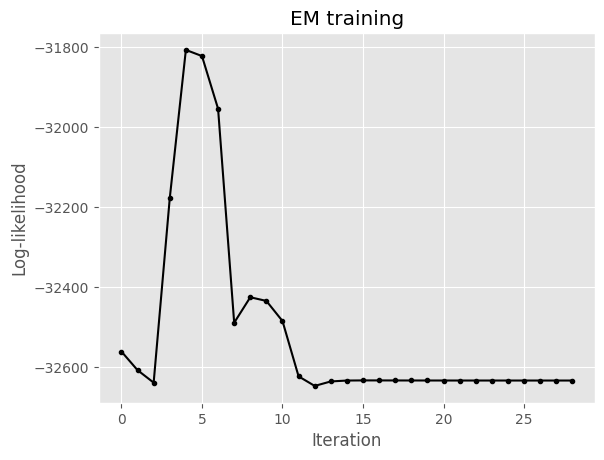

In [74]:
reg_coef = 5e-1
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    K_components=K_components,
    U=feat_mat.to_numpy(),
    X=X,
    Y=Y,
    beta=beta,
    reg_coef=reg_coef,
    tol=tol,
    seed=seed,
    allow_singular=False,
)

In [75]:
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

(array([[ 9.92799976e+03,  2.19540095e+04,  2.06088291e+02,
          1.66051375e+00,  3.99909764e-01,  7.46846193e-02,
          2.58017648e+04,  7.61146701e-01,  7.49202985e-01,
         -9.01176603e-01, -9.36830486e-01,  6.10938463e-01,
          6.23707203e-01,  8.84437062e+00,  8.89017815e+00,
          8.48576624e+00,  8.46286475e+00,  1.03044145e+01,
          3.41127315e-02,  5.48582436e-02, -3.52068711e-05,
         -1.13679014e-04,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  8.69946833e-01,
          2.59562744e+01,  9.31618929e-02, -6.44514938e-02,
         -1.01891928e-01, -1.24692266e+01,  2.13302872e-01],
        [ 1.31089407e+04,  1.02751138e+04,  8.29645985e+02,
          2.53165650e+00,  4.59305661e-01,  7.19804145e-01,
         -1.57635249e+03,  1.21849087e+00,  1.23123711e+00,
         -9.57458702e-01, -9.38931919e-01,  9.69211948e-01,
          9.72792253e-01,  1.31086403e+01,  1.32161264e+01,
          1.42381448e+01,  1.40642353e+

In [76]:
# np.round(gmm.means_), np.round(gmm.covariances_)

In [77]:
y_cls_win, clust_labels_pred

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [78]:
print_metrics(X=feat_mat, labels_true=y_cls_win, labels_pred=clust_labels_pred)

Silhouette: 0.3521406248226352
Completeness: 0.16942219780467754
Fowlkes-Mallows index: 0.46154806163530004
Homogeneity: 0.11044428664405494
Mutual Information: 0.12133070660581463
Adjusted mutual information: 0.13054655432629741
Normalized Mutual Information: 0.13371886108522793
Rand index: 0.4832497115719997
Adjusted rand index: 0.02835232146710605
V-measure: 0.13371886108522793


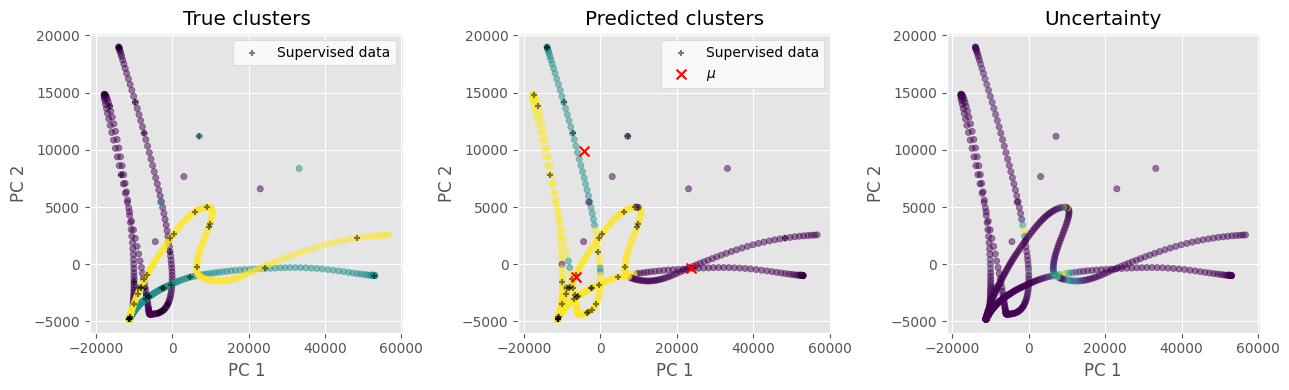

In [79]:
plot_cluster_res3(
    U=feat_mat,
    X=X,
    Y=Y,
    labels_gt=y_cls_win,
    labels_pred=clust_labels_pred,
    gamma_resp=gamma_resp,
    mu=mu,
)

## Synthetic hierarchical (toy) data

In [80]:
# def plot_gaussian_hmm(
#     hmm, params, emissions, states, title="Emission Distributions", alpha=0.25
# ):
#     lim = 1.1 * abs(emissions).max()
#     XX, YY = jnp.meshgrid(jnp.linspace(-lim, lim, 100), jnp.linspace(-lim, lim, 100))
#     grid = jnp.column_stack((XX.ravel(), YY.ravel()))

#     plt.figure()
#     for k in range(hmm.num_states):
#         lls = hmm.emission_distribution(params, k).log_prob(grid)
#         plt.contour(
#             XX, YY, jnp.exp(lls).reshape(XX.shape), cmap=white_to_color_cmap(COLORS[k])
#         )
#         plt.plot(
#             emissions[states == k, 0],
#             emissions[states == k, 1],
#             "o",
#             mfc=COLORS[k],
#             mec="none",
#             ms=3,
#             alpha=alpha,
#         )

#     plt.plot(emissions[:, 0], emissions[:, 1], "-k", lw=1, alpha=alpha)
#     plt.xlabel("$y_1$")
#     plt.ylabel("$y_2$")
#     plt.title(title)
#     plt.gca().set_aspect(1.0)
#     plt.tight_layout()

In [81]:
def generate_two_level_hmm_sequence(
    seq_length,
    n_meta,
    n_sub,
    obs_dim,
    A_meta,
    A_sub,
    pi_meta,
    pi_sub,
    means,
    covariances,
    seed=None,
):
    """
    Generate sequence from a 2-level HMM.

    Parameters:
    - A_meta: (n_meta, n_meta) meta-state transition matrix
    - A_sub: (n_meta, n_sub, n_sub) sub-state transition (depends on meta)
    - pi_meta: (n_meta,) initial meta distribution
    - pi_sub: (n_meta, n_sub) initial sub distribution given meta
    - means: (n_meta, n_sub) observation means
    - covariances: (n_meta, n_sub, obs_dim, obs_dim) covariance matrices
    """
    rng = np.random.default_rng(seed)

    # Initialize arrays
    meta_states = np.zeros(seq_length, dtype=int)
    sub_states = np.zeros(seq_length, dtype=int)
    observations = np.zeros((seq_length, obs_dim))

    # Sample initial states
    meta_states[0] = rng.choice(n_meta, p=pi_meta)
    sub_states[0] = rng.choice(n_sub, p=pi_sub[meta_states[0]])

    # Generate first observation (multi-dimensional)
    observations[0] = rng.multivariate_normal(
        mean=means[meta_states[0], sub_states[0]],
        cov=covariances[meta_states[0], sub_states[0]],
    )

    # Generate rest of the sequence
    for t in range(1, seq_length):
        # Meta-state transition (depends only on previous meta)
        meta_states[t] = rng.choice(n_meta, p=A_meta[meta_states[t - 1]])

        # Check if meta-state changed
        if meta_states[t] != meta_states[t - 1]:
            # RESET: Sample sub-state from initial distribution
            sub_states[t] = rng.choice(n_sub, p=pi_sub[meta_states[t]])
        else:
            # Normal transition within same meta-state
            sub_states[t] = rng.choice(
                n_sub, p=A_sub[meta_states[t], sub_states[t - 1]]
            )

        # Multi-dimensional observation (depends on current meta and sub)
        observations[t] = rng.multivariate_normal(
            mean=means[meta_states[t], sub_states[t]],
            cov=covariances[meta_states[t], sub_states[t]],
            # size=(obs_dim),
        )

    return meta_states, sub_states, observations

In [82]:
n_meta = 3
n_sub = 4
obs_dim = 5

# Transition matrices
A_meta = np.array(
    [
        [0.8, 0.1, 0.1],  # from meta 0
        [0.1, 0.8, 0.1],  # from meta 1
        [0.1, 0.1, 0.8],  # from meta 2
    ]
)

# Sub-state transitions for each meta-state
A_sub = np.zeros((n_meta, n_sub, n_sub))
# Meta 0: tends to stay in same sub-state
A_sub[0] = np.array(
    [
        [0.7, 0.1, 0.1, 0.1],
        [0.1, 0.7, 0.1, 0.1],
        [0.1, 0.1, 0.7, 0.1],
        [0.1, 0.1, 0.1, 0.7],
    ]
)
# Meta 1: tends to increase sub-state
A_sub[1] = np.array(
    [
        [0.4, 0.6, 0.0, 0.0],
        [0.0, 0.4, 0.6, 0.0],
        [0.0, 0.0, 0.4, 0.6],
        [0.6, 0.0, 0.0, 0.4],
    ]
)
# Meta 2: tends to decrease sub-state
# A_sub[2] = np.array(
#     [
#         [0.4, 0.0, 0.0, 0.6],
#         [0.6, 0.4, 0.0, 0.0],
#         [0.0, 0.6, 0.4, 0.0],
#         [0.0, 0.0, 0.6, 0.4],
#     ]
# )
# Meta 2: tends to increase sub-state
A_sub[2] = np.array(
    [
        [0.4, 0.6, 0.0, 0.0],
        [0.0, 0.4, 0.6, 0.0],
        [0.0, 0.0, 0.4, 0.6],
        [0.6, 0.0, 0.0, 0.4],
    ]
)

# Initial distributions
pi_meta = np.array([0.34, 0.33, 0.33])  # uniform-ish
# pi_sub = np.array(
#     [
#         [0.4, 0.3, 0.2, 0.1],  # given meta 0
#         [0.1, 0.2, 0.3, 0.4],  # given meta 1
#         [0.25, 0.25, 0.25, 0.25],  # given meta 2
#     ]
# )
pi_sub = np.array(
    [
        [0.6, 0.1, 0.2, 0.1],  # given meta 0
        [0.2, 0.6, 0.1, 0.1],  # given meta 1
        [0.0, 0.2, 0.6, 0.2],  # given meta 2
    ]
)


# Multi-dimensional observation parameters
means = np.zeros((n_meta, n_sub, obs_dim))
covariances = np.zeros((n_meta, n_sub, obs_dim, obs_dim))

# # Make means distinct for different meta-sub combinations
# for m in range(n_meta):
#     for s in range(n_sub):
#         means[m, s] = m * 10 + s * 2  # e.g., meta0: 0,2,4,6; meta1: 10,12,14,16; etc.

# Define different (meta, sub) pairs to have distinct 2D Gaussian distributions
for m in range(n_meta):
    for s in range(n_sub):
        # Different centers for each state
        means[m, s, :] = [
            m * 10 + s * 2,
            m * 5 + s * 1.5,
            m * 15 + s * 2.5,
            m * 20 + s * 1,
            m * 0 + s * 0,
        ]

        # Different covariance structures
        if m == 0:  # Meta 0: isotropic
            covariances[m, s] = np.eye(obs_dim) * (s + 1)
        elif m == 1:  # Meta 1: correlated
            # covariances[m, s] = np.array([[2.0, 0.8], [0.8, 1.0]]) * (s + 1)
            covariances[m, s] = np.array(
                [
                    [3.0, 0.8, 0.8, 0.0, 0.0],
                    [0.8, 3.0, 0.8, 0.0, 0.0],
                    [0.0, 0.8, 2.0, 0.8, 0.0],
                    [0.0, 0.0, 0.8, 2.0, 0.8],
                    [0.0, 0.0, 0.8, 0.8, 2.0],
                ]
            ) * (s + 1)
        else:  # Meta 2: anti-correlated
            # covariances[m, s] = np.array([[2.0, -0.5], [-0.5, 1.0]]) * (s + 1)
            covariances[m, s] = np.array(
                [
                    [2.0, -0.5, -0.5, 0.0, 0.0],
                    [-0.5, 2.0, -0.5, 0.0, 0.0],
                    [0.0, -0.5, 1.0, -0.5, 0.0],
                    [0.0, 0.0, -0.5, 1.0, -0.5],
                    [0.0, 0.0, -0.5, -0.5, 1.0],
                ]
            ) * (s + 1)
        covariances[m, s] = 1 / 2 * (covariances[m, s] + covariances[m, s].T)

In [83]:
# covariances

In [84]:
# Generate sequence
meta_states, sub_states, observations = generate_two_level_hmm_sequence(
    seq_length=seq_length,
    n_meta=n_meta,
    n_sub=n_sub,
    obs_dim=obs_dim,
    A_meta=A_meta,
    A_sub=A_sub,
    pi_meta=pi_meta,
    pi_sub=pi_sub,
    means=means,
    covariances=covariances,
    seed=seed,
)

print(f"Meta states:  {meta_states}")
print(f"Sub states:   {sub_states}")
print(f"Observations:\n{np.round(observations[:10, :], 2)}\n [...]")

Meta states:  [2 2 2 ... 0 0 0]
Sub states:   [2 2 2 ... 2 3 2]
Observations:
[[22.94 15.56 37.2  37.97  1.64]
 [23.81 10.08 36.85 42.68 -0.74]
 [24.43 14.29 33.52 43.96 -1.38]
 [26.93 14.38 36.46 43.22  1.24]
 [ 8.87  1.73 14.71 19.51  1.07]
 [11.57  7.94 20.61 22.42  0.58]
 [12.32  8.91 20.87 20.52 -0.83]
 [ 5.09  0.48  4.45  1.19 -1.11]
 [ 0.78  2.87  0.12  0.53  0.23]
 [ 3.12  1.01  1.85  2.21 -0.27]]
 [...]


In [85]:
observations.shape

(1024, 5)

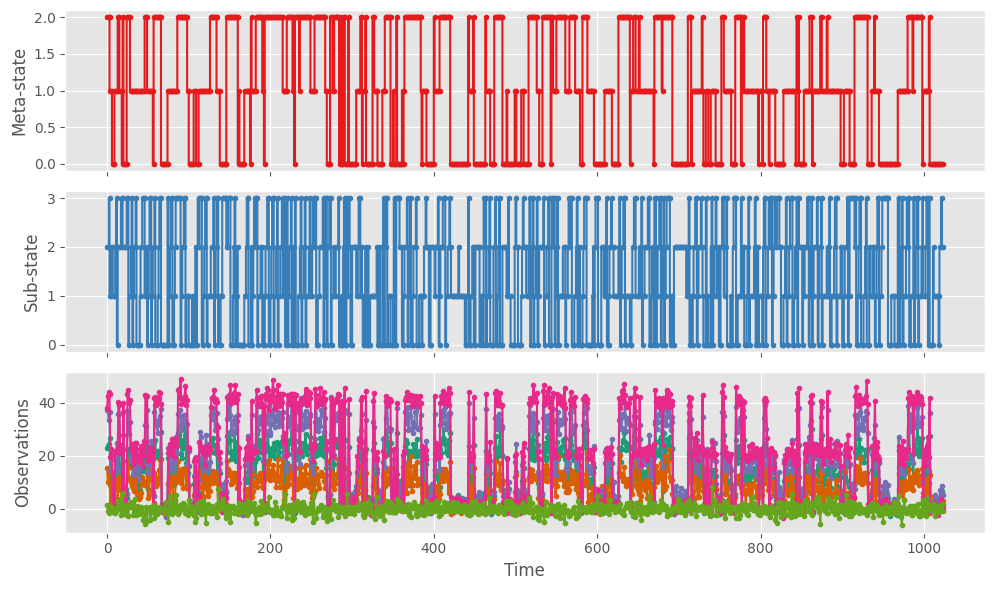

In [86]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["Set1"].colors
    cmap2 = plt.colormaps["Dark2"].colors
    fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 6))
    axes[0].step(meta_states, ".-", c=cmap[0])
    axes[0].set_ylabel("Meta-state")
    axes[1].step(sub_states, ".-", c=cmap[1])
    axes[1].set_ylabel("Sub-state")
    for obsi in range(obs_dim):
        axes[2].plot(observations[:, obsi], ".-", c=cmap2[obsi])  # , c=cmap[2])
    axes[2].set_ylabel("Observations")
    axes[2].set_xlabel("Time")
    plt.tight_layout()
    plt.show()

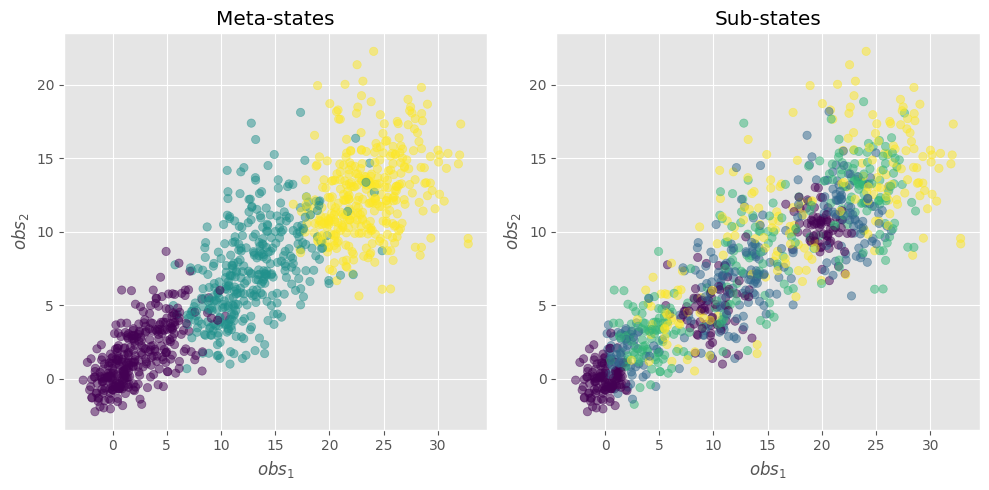

In [87]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
    ax[0].scatter(observations[:, 0], observations[:, 1], alpha=0.5, c=meta_states)
    ax[1].scatter(observations[:, 0], observations[:, 1], alpha=0.5, c=sub_states)
    ax[0].set_title("Meta-states")
    ax[1].set_title("Sub-states")
    for axi in ax:
        axi.set_xlabel(f"$obs_1$")
        axi.set_ylabel(f"$obs_2$")
    fig.tight_layout()
    plt.show()

In [88]:
windows = sliding_window(series=observations, window_size=window_size, step=window_step)
windows.shape

(201, 20, 5)

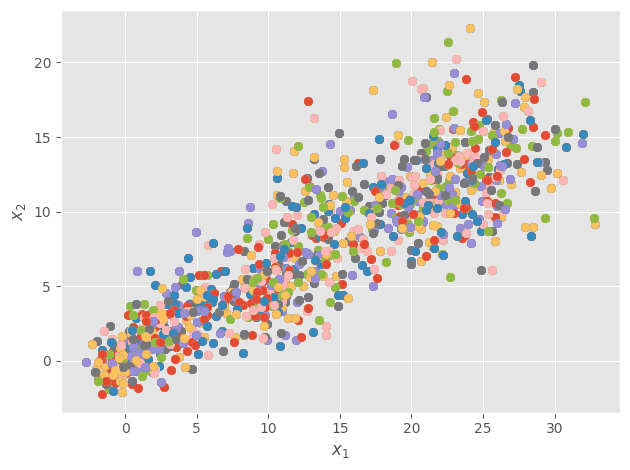

In [89]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots()
    for idx in range(windows.shape[0]):
        ax.scatter(windows[idx, :, 0], windows[idx, :, 1])  # , color=cmap[idx])
    ax.set_xlabel(f"$x_1$")
    ax.set_ylabel(f"$x_2$")
    fig.tight_layout()
    plt.show()

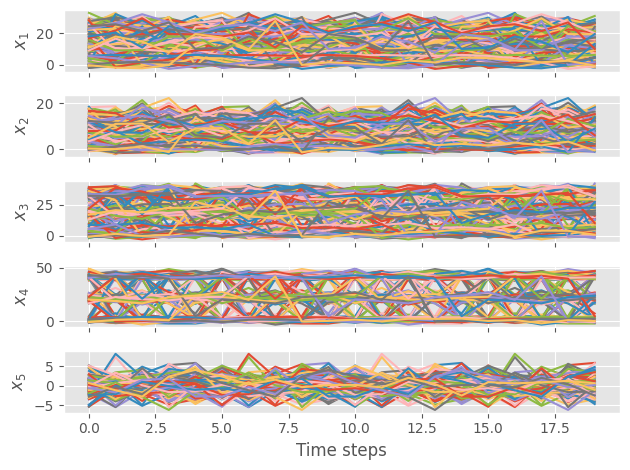

In [90]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots(windows.shape[-1], 1, sharex=True)
    for idx in range(windows.shape[-1]):
        for jdx in range(windows.shape[0]):
            ax[idx].plot(windows[jdx, :, idx])  # , c=cmap[jdx])
        ax[idx].set_ylabel(f"$x_{idx + 1}$")
    ax[idx].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

In [91]:
feat_mat = extract_features(windows)
feat_mat.shape

(201, 69)

In [92]:
for col in range(feat_mat.shape[1]):
    if np.any(np.isnan(feat_mat[:, col])):
        feat_mat = np.delete(arr=feat_mat, obj=col, axis=1)
feat_mat = pd.DataFrame(feat_mat)
feat_mat

,0,1,2,3,4,5,6,7,8,9,...,59,60,61,62,63,64,65,66,67,68
0,5309.710880,1715.018059,11995.584216,15009.528201,99.346315,926.786575,0.763659,0.953137,0.790478,0.812107,...,1.0,18.474087,0.457070,-0.044619,-0.243340,-0.238790,-0.114295,1.016047,-63.086589,0.898502
1,3737.859604,1061.485940,8046.610227,9164.488927,103.868960,702.664741,1.956361,0.921991,0.740627,0.815052,...,1.0,14.870882,0.596520,0.603298,-0.147804,0.314613,0.256456,0.998356,2062.489192,1.041180
2,5512.416626,1830.360341,12112.166002,15990.933899,116.742594,952.718338,1.540105,0.953048,0.821130,0.594904,...,1.0,18.858054,0.655690,-0.089075,0.133048,-0.106546,-0.245232,0.535868,768.821665,0.903935
3,5230.394457,1825.601860,11051.883604,14817.065776,132.659682,898.645211,2.187019,0.951371,0.816080,0.637961,...,1.0,18.181751,0.600253,0.019980,0.166791,0.054384,-0.131839,0.340255,1300.382054,0.900477
4,4749.216609,1953.930971,9733.344807,13813.028578,65.516572,879.352565,2.124440,0.846356,0.869614,0.915605,...,1.0,17.411214,0.591098,0.322749,0.366168,0.334436,-0.029713,0.137564,-3563.590573,0.916103
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,10070.319290,2494.485312,20670.526910,30171.287946,62.409742,1521.790478,4.238987,0.683141,0.755358,0.241180,...,1.0,25.193060,0.443644,-0.462079,-0.109925,-1.688856,-2.550199,0.201685,2084.714470,0.737257
197,8803.136285,2295.040792,17770.070680,24832.797736,90.975950,1342.956083,4.022200,0.775391,0.809935,0.397912,...,1.0,23.193107,0.552565,-0.348397,-0.692503,-0.724875,-1.020051,0.431842,-8479.518897,0.767653
198,8076.830221,2029.395540,14849.176584,20402.606375,86.408889,1154.530959,2.861276,0.847304,0.852912,0.477664,...,1.0,21.317696,0.562651,-0.558741,-0.883454,-0.902381,-0.684270,0.021759,-11239.734975,0.874584
199,4762.422250,1313.896513,8709.361931,11851.865773,80.860141,762.995587,1.515522,0.877824,0.873732,0.742524,...,1.0,16.345766,0.456017,0.213905,0.075601,0.049485,0.312743,0.001929,-4324.892962,1.144158


In [93]:
feat_mat = pd.DataFrame(observations)
feat_mat

,0,1,2,3,4
0,22.940814,15.556814,37.197462,37.966697,1.637203
1,23.811693,10.079408,36.853285,42.682567,-0.740727
2,24.425144,14.285568,33.523082,43.963736,-1.384405
3,26.930447,14.382339,36.462963,43.223479,1.238360
4,8.872408,1.733691,14.711358,19.505542,1.071051
...,...,...,...,...,...
1019,-0.693081,-0.635234,0.837853,-0.042147,-1.046182
1020,3.052952,3.572248,7.147235,-0.267124,-0.078180
1021,6.146288,0.697322,5.986919,3.786652,-0.322815
1022,6.689634,5.664705,8.622561,1.036055,1.980533


### Meta-states clustering

In [94]:
K_components = n_meta

In [95]:
y_cls_win = np.round(
    np.mean(
        sliding_window(series=meta_states, window_size=window_size, step=window_step),
        axis=1,
    )
).astype(int)
y_cls_win

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2,
       2, 2, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1,
       1, 2, 2, 2, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 2, 2, 2,
       1, 1, 0])

In [96]:
# supervised_sample_size = 20
# idx_superv = np.random.choice(
#     np.arange(y_cls_win.shape[0]), size=supervised_sample_size, replace=False
# )
# Y = np.zeros((len(idx_superv), K_components))
# for idxi, idx_val in enumerate(idx_superv):
#     Y[idxi, int(y_cls_win[int(idx_val)])] = 1
# # Y = labels_gt[idx_superv]
# X = feat_mat.iloc[idx_superv, :]
# X.shape, Y

In [97]:
supervised_sample_size = 15
X, Y, _ = select_supervised_data(
    total_sample_size=supervised_sample_size,
    labels_gt=y_cls_win,
    K_components=K_components,
    U=feat_mat.to_numpy(),
)
X.shape, Y

((15, 5),
 array([[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.]]))

Iteration   0/300 -- Log-likelihood: -8140.140320865674

--- Converged at iteration 4 ---



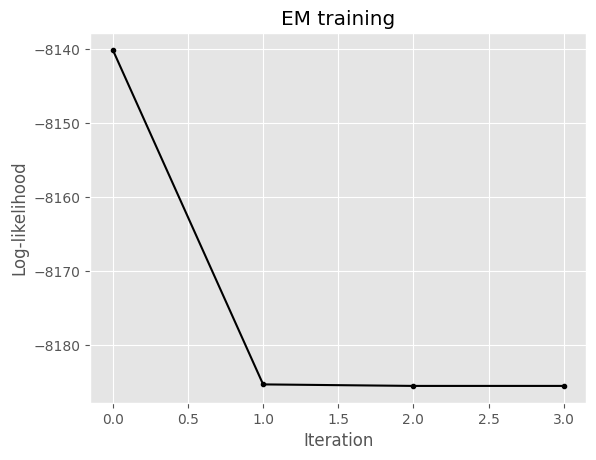

In [98]:
reg_coef = 1e-2
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    K_components=K_components,
    U=feat_mat.to_numpy(),
    X=X,
    Y=Y,
    beta=beta,
    reg_coef=reg_coef,
    tol=tol,
    seed=seed,
    allow_singular=False,
)

In [99]:
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

(array([[23.33371285, 12.5025419 , 33.93401735, 41.45473255, -0.18101695],
        [12.91670603,  7.43436756, 18.92366681, 21.47493346,  0.06533488],
        [ 2.52640547,  1.77549636,  3.21025506,  1.31612585,  0.12217952]]),
 array([[[10.09372309,  0.        ,  0.        ,  0.        ,
           0.        ],
         [ 0.        ,  8.25560123,  0.        ,  0.        ,
           0.        ],
         [ 0.        ,  0.        ,  9.9248979 ,  0.        ,
           0.        ],
         [ 0.        ,  0.        ,  0.        ,  4.31564532,
           0.        ],
         [ 0.        ,  0.        ,  0.        ,  0.        ,
           2.50576118]],
 
        [[11.90179443,  0.        ,  0.        ,  0.        ,
           0.        ],
         [ 0.        , 10.23757682,  0.        ,  0.        ,
           0.        ],
         [ 0.        ,  0.        , 13.57294589,  0.        ,
           0.        ],
         [ 0.        ,  0.        ,  0.        ,  5.52326147,
           0.       

In [100]:
y_cls_win, clust_labels_pred

(array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2,
        2, 2, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1,
        1, 2, 2, 2, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 2, 2, 2,
        1, 1, 0]),
 array([0, 0, 0, ..., 2, 2, 2], shape=(1024,)))

In [101]:
print_metrics(X=feat_mat, labels_true=y_cls_win, labels_pred=clust_labels_pred)

Silhouette: 0.7089622162144964


ValueError: Found input variables with inconsistent numbers of samples: [201, 1024]

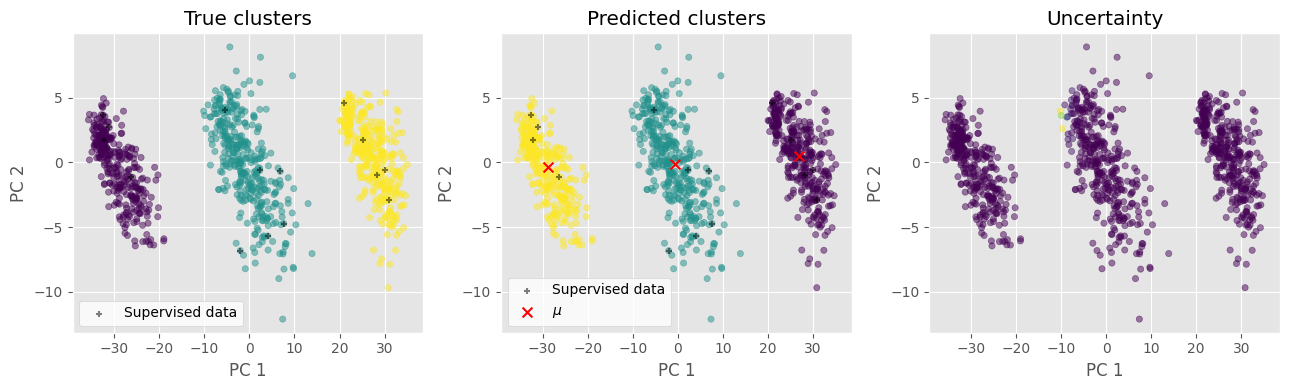

In [102]:
plot_cluster_res3(
    U=feat_mat,
    X=X,
    Y=Y,
    # labels_gt=y_cls_win,
    labels_gt=meta_states,
    labels_pred=clust_labels_pred,
    gamma_resp=gamma_resp,
    mu=mu,
)

### Sub-states clustering

In [103]:
K_components = n_sub

In [104]:
y_cls_win = np.round(
    np.mean(
        sliding_window(series=sub_states, window_size=window_size, step=window_step),
        axis=1,
    )
).astype(int)
y_cls_win

array([2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 2, 1, 1, 1, 2,
       2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 2, 2, 1, 1, 1,
       1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 2, 2, 1, 2,
       2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2, 1, 1,
       1, 1, 1, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 1, 1])

In [105]:
# supervised_sample_size = 30
# idx_superv = np.random.choice(
#     np.arange(y_cls_win.shape[0]), size=supervised_sample_size, replace=False
# )
# Y = np.zeros((len(idx_superv), K_components))
# for idxi, idx_val in enumerate(idx_superv):
#     Y[idxi, int(y_cls_win[int(idx_val)])] = 1
# # Y = labels_gt[idx_superv]
# X = feat_mat.iloc[idx_superv, :]
# X.shape, Y

In [106]:
supervised_sample_size = 30
X, Y, _ = select_supervised_data(
    total_sample_size=supervised_sample_size,
    labels_gt=y_cls_win,
    K_components=K_components,
    U=feat_mat.to_numpy(),
)
X.shape, Y

((30, 5),
 array([[0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.]]))

Iteration   0/300 -- Log-likelihood: -10928.35516881786
Iteration  10/300 -- Log-likelihood: -11150.027487655349
Iteration  20/300 -- Log-likelihood: -11168.032789699342
Iteration  30/300 -- Log-likelihood: -11197.469353787048
Iteration  40/300 -- Log-likelihood: -11212.114201325792
Iteration  50/300 -- Log-likelihood: -11216.755454323245
Iteration  60/300 -- Log-likelihood: -11218.225316728418
Iteration  70/300 -- Log-likelihood: -11218.714715900078
Iteration  80/300 -- Log-likelihood: -11218.881772912187
Iteration  90/300 -- Log-likelihood: -11218.939347293182
Iteration 100/300 -- Log-likelihood: -11218.95925801475
Iteration 110/300 -- Log-likelihood: -11218.966151965535
Iteration 120/300 -- Log-likelihood: -11218.968539949761
Iteration 130/300 -- Log-likelihood: -11218.96936724002
Iteration 140/300 -- Log-likelihood: -11218.96965385988
Iteration 150/300 -- Log-likelihood: -11218.969753162832
Iteration 160/300 -- Log-likelihood: -11218.969787567774

--- Converged at iteration 168 ---

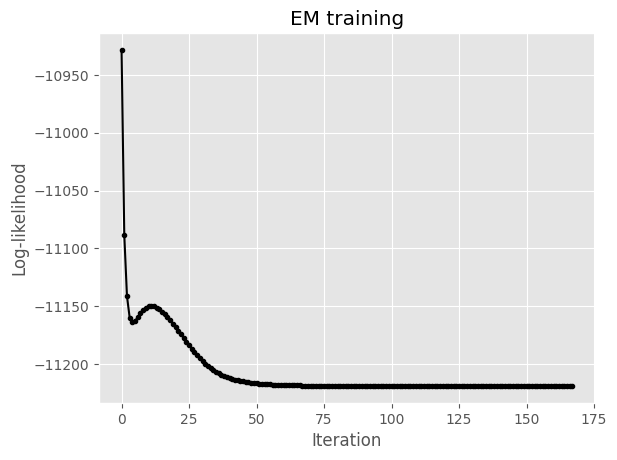

In [108]:
reg_coef = 1e-2
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    K_components=K_components,
    U=feat_mat.to_numpy(),
    X=X,
    Y=Y,
    beta=beta,
    reg_coef=reg_coef,
    seed=seed,
    allow_singular=False,
)

In [109]:
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

(array([[23.79401649, 12.73112092, 34.55735802, 42.24475217, -0.17803069],
        [ 9.43986505,  4.50352404, 14.1686036 , 18.28853438, -0.0953266 ],
        [ 2.67790999,  1.90178885,  3.50448911,  1.69915336,  0.11019848],
        [15.12600927,  9.27585313, 21.94940231, 23.46620236,  0.2108226 ]]),
 array([[[10.32737997,  0.        ,  0.        ,  0.        ,
           0.        ],
         [ 0.        ,  8.40111553,  0.        ,  0.        ,
           0.        ],
         [ 0.        ,  0.        , 10.25325136,  0.        ,
           0.        ],
         [ 0.        ,  0.        ,  0.        ,  4.66875013,
           0.        ],
         [ 0.        ,  0.        ,  0.        ,  0.        ,
           2.54146031]],
 
        [[ 4.1540546 ,  0.        ,  0.        ,  0.        ,
           0.        ],
         [ 0.        ,  2.92476403,  0.        ,  0.        ,
           0.        ],
         [ 0.        ,  0.        ,  4.02924687,  0.        ,
           0.        ],
       

In [110]:
print_metrics(X=feat_mat, labels_true=y_cls_win, labels_pred=clust_labels_pred)

Silhouette: 0.5627435777394201


ValueError: Found input variables with inconsistent numbers of samples: [201, 1024]

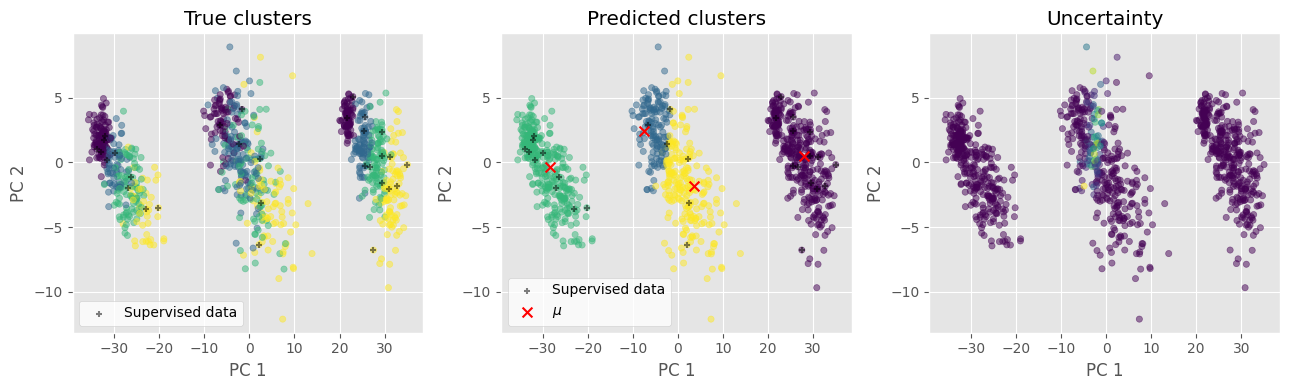

In [111]:
plot_cluster_res3(
    U=feat_mat,
    X=X,
    Y=Y,
    # labels_gt=y_cls_win,
    labels_gt=sub_states,
    labels_pred=clust_labels_pred,
    gamma_resp=gamma_resp,
    mu=mu,
)

## IROS data

In [112]:
# data_path_root = Path("../table-task-ur5e")
data_path_root = Path("..") / "sdl" / "data"
assert data_path_root.exists(), "Data path doesn't exist"

In [113]:
ground_truth_segm_file = data_path_root.parent / "segm_ground_truth.json"
assert ground_truth_segm_file.exists(), "Ground truth file not found"

In [114]:
def plot_xyzgrip(traj, supervised_samples=None):
    with plt.style.context("ggplot"):
        fig, ax = plt.subplots(
            nrows=len(traj.columns) - 1,
            ncols=1,
            sharex=True,  # figsize=(8, 5)
        )
        # cmap = mpl.colormaps.get("tab10").colors
        jdx = 0
        for idx, axi in enumerate(range(len(traj.columns))):
            if traj.columns[idx] == "timestamp":
                continue
            ax[jdx].plot(
                traj.timestamp, traj[traj.columns[idx]], color="k"
            )  # cmap[idx])
            ax[jdx].set_ylabel(traj.columns[idx])
            # if supervised_samples is not None:
            #     ax[jdx].scatter(
            #         traj.timestamp, supervised_samples[:, idx]#, color="k"
            #     )  # cmap[idx])
            jdx += 1
        ax[-1].set_xlabel("Time")
        # ax.legend(loc="best")
        # axi.legend(bbox_to_anchor=(1.0, 1.02))
        fig.autofmt_xdate()
        fig.tight_layout()
        plt.show()

In [115]:
def smooth_traj(traj, nb_points=256, smoothing_factor=0):
    new_index = np.linspace(start=traj.index.start, stop=traj.index.stop, num=nb_points)
    for idx, col in enumerate(traj.columns):
        if idx == 0:
            traj_smooth = pd.DataFrame(
                {
                    col: make_splrep(x=traj.index, y=traj[col], s=smoothing_factor)(
                        new_index
                    ),
                }
            )
        else:
            traj_smooth[col] = make_splrep(traj.index, traj[col], s=smoothing_factor)(
                new_index
            )
    return traj_smooth

In [116]:
def preprocessing(traj, resample_num):
    traj_float = traj.drop(columns=["timestamp"])
    traj_down = smooth_traj(traj=traj_float, nb_points=resample_num)
    # plot_processed_traj(X_down=X_down)
    minmaxscaler = MinMaxScaler(feature_range=(0, 1))
    traj_down_scaled = minmaxscaler.fit_transform(traj_down)
    return traj_down, minmaxscaler, traj_down_scaled

In [117]:
def plot_supervised_data(traj, supervised_samples, idx_superv):
    ts = np.arange(traj_all.shape[0])
    with plt.style.context("ggplot"):
        fig, ax = plt.subplots(
            nrows=len(traj.columns) - 1,
            ncols=1,
            sharex=True,
            figsize=(8, 5),
        )
        cmap = mpl.colormaps.get("tab10").colors
        jdx = 0
        for idx, axi in enumerate(range(len(traj.columns))):
            if traj.columns[idx] == "label_true":
                continue
            for label_i, label_v in enumerate(traj.label_true.unique()):
                ax[jdx].plot(
                    ts[traj.label_true == label_i],
                    traj[traj.columns[idx]][traj.label_true == label_i],
                    color=cmap[label_i],
                )
            ax[jdx].set_ylabel(traj.columns[idx])
            ax[jdx].scatter(ts[idx_superv], supervised_samples[:, idx], color="k")
            jdx += 1
        ax[-1].set_xlabel("Time")
        # ax.legend(loc="best")
        # axi.legend(bbox_to_anchor=(1.0, 1.02))
        fig.autofmt_xdate()
        fig.tight_layout()
        plt.show()

{'hdf5': 'pour-1.h5',
 'segments': {'grasping': {'end': 1769722781, 'ini': 1769722779},
              'pouring': {'end': 1769722793, 'ini': 1769722781},
              'reaching': {'end': 1769722779, 'ini': 1769722774},
              'releasing': {'end': 1769722799, 'ini': 1769722793}},
 'synchro_ts': 0,
 'synchro_vid': 0,
 'video': 'pour-1.MOV'}
['gripper_info', 'joint_state_info', 'transform_info', 'wrench_info']


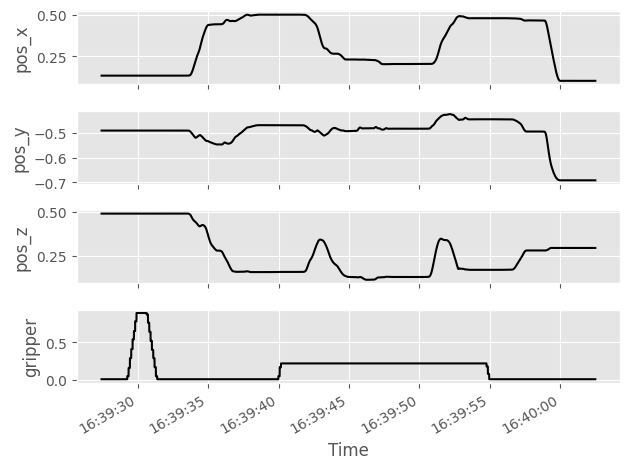

{'hdf5': 'set-table-1.h5',
 'segments': {'grasping': [{'end': 1769722515, 'ini': 1769722513},
                           {'end': 1769722528, 'ini': 1769722526}],
              'placing': [{'end': 1769722520, 'ini': 1769722515},
                          {'end': 1769722532, 'ini': 1769722528}],
              'reaching': [{'end': 1769722513, 'ini': 1769722509},
                           {'end': 1769722526, 'ini': 1769722523}],
              'releasing': [{'end': 1769722523, 'ini': 1769722520},
                            {'end': 1769722534, 'ini': 1769722532}]},
 'synchro_ts': 0,
 'synchro_vid': 0,
 'video': 'set-table-1.MOV'}
['gripper_info', 'joint_state_info', 'transform_info', 'wrench_info']


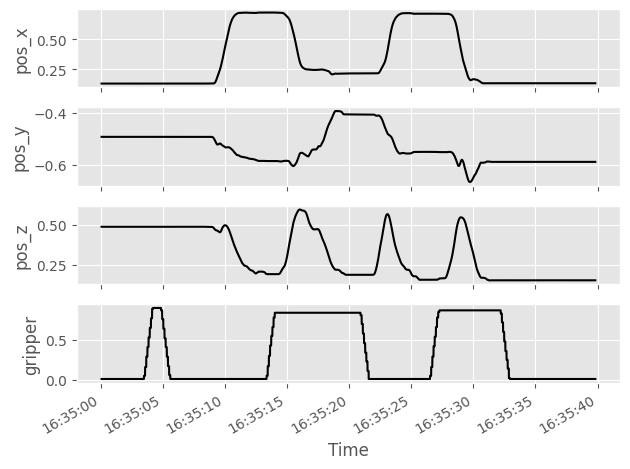

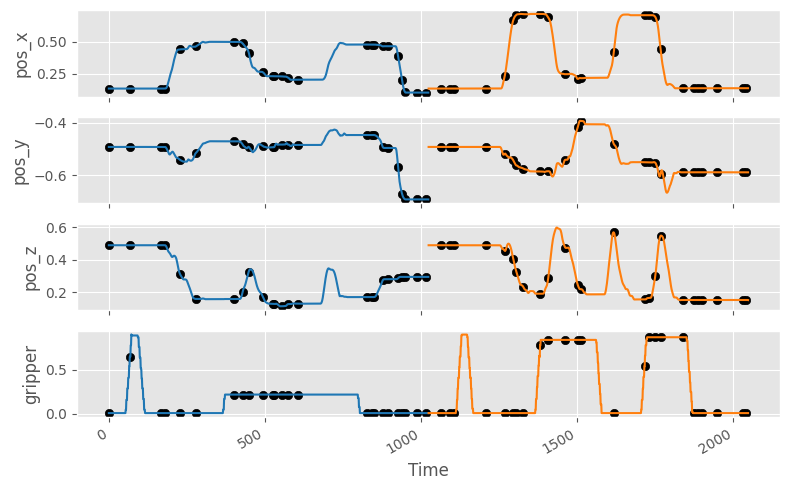

In [118]:
filenums = [2, 4]  # Subtasks
supervised_sample_size = 50

traj_all = []
for file_i, file_val in enumerate(filenums):
    gt_segm_dict, video_file, hdf5_file = get_gtdict_filenames(
        ground_truth_segm_file=ground_truth_segm_file, filenum=file_val
    )
    pprint(gt_segm_dict)
    hdf5_path = data_path_root / hdf5_file
    video_path = data_path_root / video_file
    joint_data, tf_data, wrench_data, gripper_data = read_h5_data(fname=hdf5_path)
    traj = ts2df(tf_data=tf_data, gripper_data=gripper_data)
    plot_xyzgrip(traj=traj)  # , supervised_data=X)
    # sublabels = gt_segm_dict["segments"].keys()
    traj_down, minmaxscaler, traj_down_scaled = preprocessing(
        traj=traj, resample_num=seq_length
    )
    # traj_down["label_true"] = [gt_segm_dict["hdf5"].replace(".h5", "") for item in range(seq_length)]
    traj_down["label_true"] = [file_i for item in range(seq_length)]
    traj_all.append(traj_down)  # <--- ToDo: Scale or not scale?

traj_all = pd.concat(traj_all)
U = traj_all.drop(columns=["label_true"]).to_numpy()

X, Y, idx_superv = select_supervised_data(
    total_sample_size=supervised_sample_size,
    labels_gt=traj_all.label_true.to_numpy(),
    K_components=K_components,
    U=U,
)
plot_supervised_data(traj=traj_all, supervised_samples=X, idx_superv=idx_superv)

In [119]:
traj_all

,pos_x,pos_y,pos_z,gripper,label_true
0,0.133346,-0.491964,0.488072,0.01,0
1,0.133354,-0.491971,0.488093,0.01,0
2,0.133342,-0.491960,0.488080,0.01,0
3,0.133357,-0.491967,0.488054,0.01,0
4,0.133336,-0.491957,0.488092,0.01,0
...,...,...,...,...,...
1019,0.135946,-0.588354,0.150829,0.01,1
1020,0.135943,-0.588373,0.150833,0.01,1
1021,0.135973,-0.588370,0.150857,0.01,1
1022,0.135935,-0.588373,0.150837,0.01,1


In [120]:
X.shape, Y

((50, 4),
 array([[1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
  

In [121]:
K_components = len(filenums)

Iteration   0/300 -- Log-likelihood: 3606.512362188488
Iteration  10/300 -- Log-likelihood: 4995.062827129454
Iteration  20/300 -- Log-likelihood: 5049.586453924288

--- Converged at iteration 21 ---



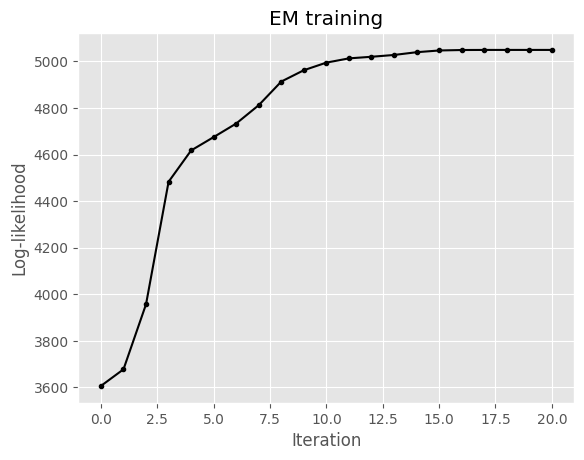

In [122]:
reg_coef = 1e-6
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    K_components=K_components,
    U=U,
    X=None,
    Y=None,
    beta=beta,
    reg_coef=reg_coef,
    tol=tol,
    seed=seed,
    allow_singular=False,
)

In [123]:
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

(array([[ 0.31655814, -0.53103651,  0.33548072,  0.84295614],
        [ 0.31588974, -0.51522631,  0.27502517,  0.08221186]]),
 array([[[0.04667066, 0.        , 0.        , 0.        ],
         [0.        , 0.0053709 , 0.        , 0.        ],
         [0.        , 0.        , 0.02346817, 0.        ],
         [0.        , 0.        , 0.        , 0.00260915]],
 
        [[0.03893531, 0.        , 0.        , 0.        ],
         [0.        , 0.00385429, 0.        , 0.        ],
         [0.        , 0.        , 0.01954851, 0.        ],
         [0.        , 0.        , 0.        , 0.0129732 ]]]),
 array([[1.94508672e-58, 1.00000000e+00],
        [1.94526920e-58, 1.00000000e+00],
        [1.94515484e-58, 1.00000000e+00],
        ...,
        [1.13502953e-58, 1.00000000e+00],
        [1.13505622e-58, 1.00000000e+00],
        [1.13540898e-58, 1.00000000e+00]], shape=(2048, 2)),
 array([1, 1, 1, ..., 1, 1, 1], shape=(2048,)),
 array([0.19194248, 0.80805752]))

In [124]:
traj_all.label_true, clust_labels_pred

(0       0
 1       0
 2       0
 3       0
 4       0
        ..
 1019    1
 1020    1
 1021    1
 1022    1
 1023    1
 Name: label_true, Length: 2048, dtype: int64,
 array([1, 1, 1, ..., 1, 1, 1], shape=(2048,)))

In [125]:
print_metrics(X=U, labels_true=traj_all.label_true, labels_pred=clust_labels_pred)

Silhouette: 0.5798451622887544
Completeness: 0.18583247608913045
Fowlkes-Mallows index: 0.6293578165258057
Homogeneity: 0.1310895535018249
Mutual Information: 0.09086435441065205
Adjusted mutual information: 0.1533828870053072
Normalized Mutual Information: 0.15373305761107553
Rand index: 0.5495279868404983
Adjusted rand index: 0.09922293334768681
V-measure: 0.15373305761107553


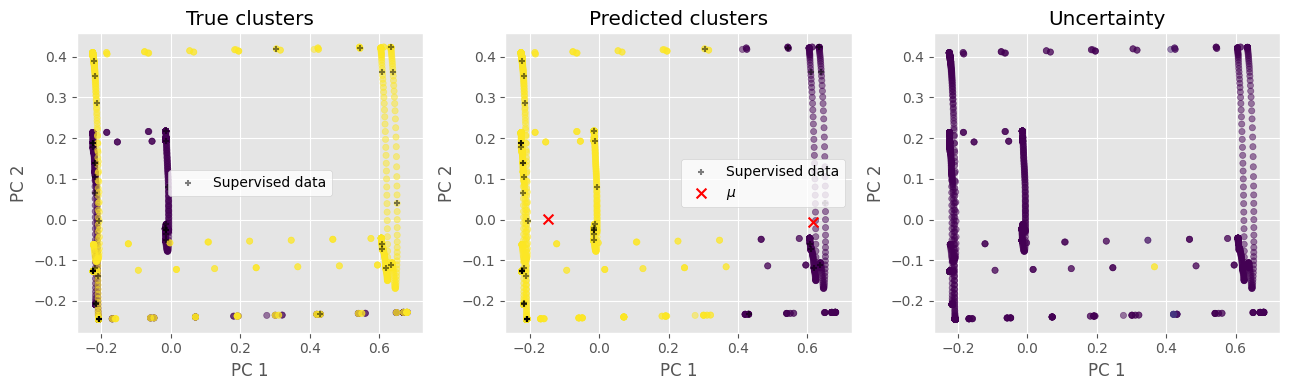

In [126]:
plot_cluster_res3(
    U=U,
    X=X,
    Y=Y,
    labels_gt=traj_all.label_true,
    labels_pred=clust_labels_pred,
    gamma_resp=gamma_resp,
    mu=mu,
)

In [127]:
def plot_cluster_res4(
    U, X, Y, labels_gt, labels_pred, gamma_resp, mu, uncertainty, proba
):

    # Transform data to first two principal components for plotting
    pca = PCA(n_components=2)
    U_pca = pca.fit_transform(U)
    X_pca = pca.transform(X)
    mu_pca = pca.transform(mu)

    with plt.style.context("ggplot"):
        fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
        ax[0, 0].scatter(U_pca[:, 0], U_pca[:, 1], alpha=0.5, s=20, c=labels_gt)
        ax[0, 0].set_title("True clusters")
        ax[0, 1].scatter(U_pca[:, 0], U_pca[:, 1], alpha=0.5, s=20, c=labels_pred)
        ax[0, 1].scatter(
            X_pca[:, 0],
            X_pca[:, 1],
            marker="+",
            c="k",
            alpha=0.5,
            s=20,
            label="Supervised data",
        )
        ax[0, 1].scatter(
            mu_pca[:, 0],
            mu_pca[:, 1],
            marker="x",
            c="r",
            alpha=1,
            s=50,
            label=r"$\mu$",
        )
        ax[0, 1].set_title("Predicted clusters")
        scat_u = ax[1, 0].scatter(
            U_pca[:, 0], U_pca[:, 1], alpha=0.5, s=20, c=uncertainty
        )
        ax[1, 0].set_title("Uncertainty")
        fig.colorbar(scat_u, ax=ax[1, 0])
        scat_p = ax[1, 1].scatter(U_pca[:, 0], U_pca[:, 1], alpha=0.5, s=20, c=proba)
        ax[1, 1].set_title("Probability")
        fig.colorbar(scat_p, ax=ax[1, 1])
        for axi in ax.flatten():
            # axi.set_xlabel("PC 1")
            # axi.set_ylabel("PC 2")
            axi.set_xlabel(f"$x_1$")
            axi.set_ylabel(f"$x_2$")
        # for axi in ax[:2]:
        ax[0, 1].legend(loc="best", facecolor="white")
        fig.tight_layout()
        plt.show()

In [128]:
gamma_resp, labels_pred, uncertainty, proba = predict(
    U=U,
    pi_mixing_prior=pi_mixing_prior,
    mu=mu,
    Sigma=Sigma,
    allow_singular=False,
    seed=seed,
)
gamma_resp, labels_pred, uncertainty, proba

(array([[1.60083004e-58, 1.00000000e+00],
        [1.60098022e-58, 1.00000000e+00],
        [1.60088611e-58, 1.00000000e+00],
        ...,
        [9.34027452e-59, 1.00000000e+00],
        [9.34049396e-59, 1.00000000e+00],
        [9.34339508e-59, 1.00000000e+00]], shape=(2048, 2)),
 array([1, 1, 1, ..., 1, 1, 1], shape=(2048,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(2048,)),
 array([16.3328852 , 16.33043487, 16.33062903, ..., 19.07090818,
        19.06408309, 18.96926772], shape=(2048,)))

In [129]:
assert np.all(labels_pred == clust_labels_pred), "Issue with labels prediction"

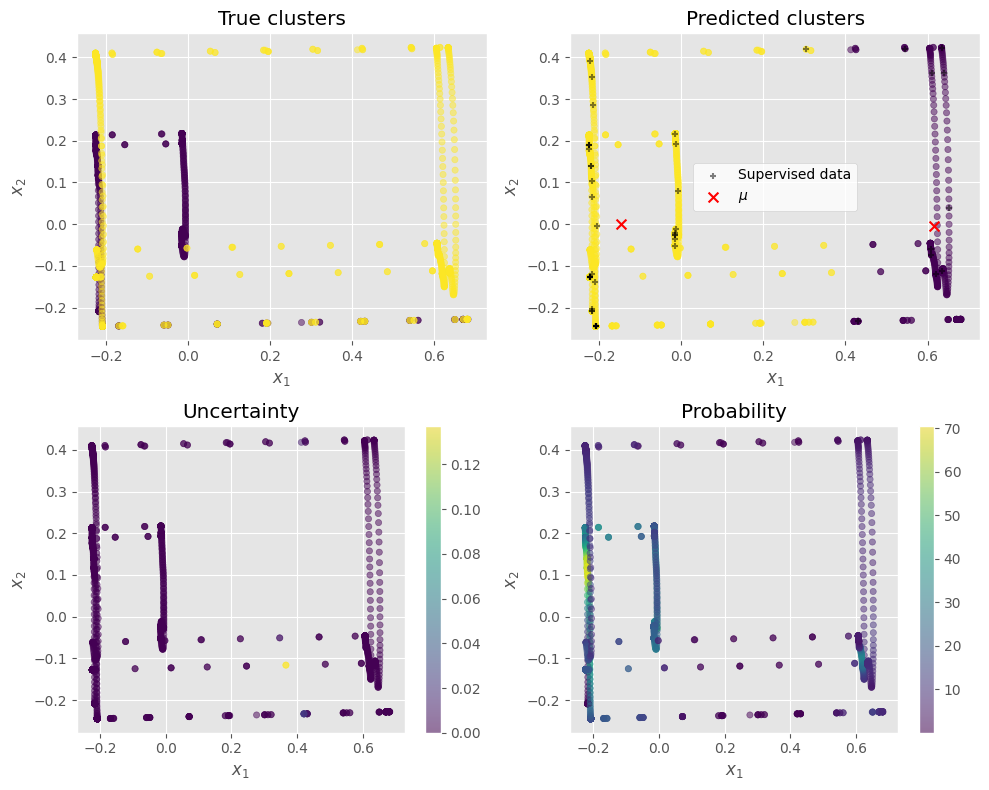

In [130]:
plot_cluster_res4(
    U=U,
    X=X,
    Y=Y,
    labels_gt=traj_all.label_true,
    labels_pred=clust_labels_pred,
    gamma_resp=gamma_resp,
    mu=mu,
    uncertainty=uncertainty,
    proba=proba,
)